# Projeto 1 — Pipeline MLP

## Energy Efficiency Dataset

Este projeto investiga a aplicação de uma Multilayer Perceptron (MLP) ao problema de eficiência energética de edifícios.

O projeto será desenvolvido em duas formulações:

- **Classificação:** classificar edifícios de acordo com sua demanda de aquecimento.
- **Regressão:** prever diretamente a carga de aquecimento (`Heating Load`).

O pipeline será implementado em PyTorch e incluirá treinamento, validação, checkpointing, monitoramento com TensorBoard, análise de gradientes, experimentos de regularização e avaliação final no conjunto de teste.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ucimlrepo import fetch_ucirepo

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

RUNS_DIR = PROJECT_ROOT / "runs"
CHECKPOINT_DIR = PROJECT_ROOT / "project_1_mlp" / "checkpoints"
ARTIFACTS_DIR = PROJECT_ROOT / "project_1_mlp" / "artifacts"

RUNS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Runs: {RUNS_DIR}")
print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Artifacts: {ARTIFACTS_DIR}")

Project root: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment
Runs: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\runs
Checkpoints: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints
Artifacts: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.13.0+cpu
Device: cpu


In [5]:
from importlib.metadata import version

packages = [
    "torch",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "jupyterlab",
    "ipykernel",
    "tensorboard",
    "ucimlrepo",
]

print("Python/PyTorch environment")

for package in packages:
    print(f"{package}: {version(package)}")

Python/PyTorch environment
torch: 2.13.0
numpy: 2.4.6
pandas: 3.0.5
scikit-learn: 1.9.0
matplotlib: 3.11.1
jupyterlab: 4.6.3
ipykernel: 7.3.0
tensorboard: 2.21.0
ucimlrepo: 0.0.7


In [6]:
from torch.utils.tensorboard import SummaryWriter

TENSORBOARD_TEST_DIR = RUNS_DIR / "project_1" / "environment_check"

writer = SummaryWriter(log_dir=TENSORBOARD_TEST_DIR)

for step in range(10):
    writer.add_scalar("Environment/Test", step ** 2, step)

writer.close()

print(f"TensorBoard test log created at: {TENSORBOARD_TEST_DIR}")

TensorBoard test log created at: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\runs\project_1\environment_check


In [7]:
%load_ext tensorboard

runs_dir_str = str(RUNS_DIR)
%tensorboard --logdir "{runs_dir_str}"

Reusing TensorBoard on port 6006 (pid 8444), started 14:15:59 ago. (Use '!kill 8444' to kill it.)

## Carregamento do dataset

O Energy Efficiency Dataset será utilizado para investigar a relação entre características arquitetônicas de edifícios e sua demanda energética. As variáveis de entrada descrevem propriedades geométricas, orientação e características de envidraçamento e os dois alvos disponíveis são `Heating Load` e `Cooling Load`.

In [8]:
energy_efficiency = fetch_ucirepo(id=242)

X = energy_efficiency.data.features.copy()
y = energy_efficiency.data.targets.copy()

print(f"Features shape: {X.shape}")
print(f"Targets shape: {y.shape}")

Features shape: (768, 8)
Targets shape: (768, 2)


In [9]:
print("First five feature rows:")
display(X.head())

print("First five target rows:")
display(y.head())

First five feature rows:


,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


First five target rows:


,Y1,Y2
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


In [10]:
print("Features:")
for column in X.columns:
    print(f"- {column}")

print("\nTargets:")
for column in y.columns:
    print(f"- {column}")

Features:
- X1
- X2
- X3
- X4
- X5
- X6
- X7
- X8

Targets:
- Y1
- Y2


In [11]:
variables = energy_efficiency.variables.copy()

display(variables)

,name,role,type,demographic,description,units,missing_values
0,X1,Feature,Continuous,None,Relative Compactness,None,no
1,X2,Feature,Continuous,None,Surface Area,None,no
2,X3,Feature,Continuous,None,Wall Area,None,no
3,X4,Feature,Continuous,None,Roof Area,None,no
4,X5,Feature,Continuous,None,Overall Height,None,no
5,X6,Feature,Integer,None,Orientation,None,no
6,X7,Feature,Continuous,None,Glazing Area,None,no
7,X8,Feature,Integer,None,Glazing Area Distribution,None,no
8,Y1,Target,Continuous,None,Heating Load,None,no
9,Y2,Target,Continuous,None,Cooling Load,None,no


In [12]:
feature_names = {
    "X1": "relative_compactness",
    "X2": "surface_area",
    "X3": "wall_area",
    "X4": "roof_area",
    "X5": "overall_height",
    "X6": "orientation",
    "X7": "glazing_area",
    "X8": "glazing_area_distribution",
}

target_names = {
    "Y1": "heating_load",
    "Y2": "cooling_load",
}

X = X.rename(columns=feature_names)
y = y.rename(columns=target_names)

print("Features:")
display(X.head())

print("Targets:")
display(y.head())

Features:


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


Targets:


,heating_load,cooling_load
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


In [13]:
print("Feature dataset information:")
X.info()

print("\nTarget dataset information:")
y.info()

Feature dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   relative_compactness       768 non-null    float64
 1   surface_area               768 non-null    float64
 2   wall_area                  768 non-null    float64
 3   roof_area                  768 non-null    float64
 4   overall_height             768 non-null    float64
 5   orientation                768 non-null    int64  
 6   glazing_area               768 non-null    float64
 7   glazing_area_distribution  768 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.1 KB

Target dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   heating_load  768 non-null    float64
 1   cooling_loa

In [14]:
missing_features = X.isna().sum()
missing_targets = y.isna().sum()

duplicate_rows = X.duplicated().sum()

print("Missing values in features:")
display(missing_features)

print("Missing values in targets:")
display(missing_targets)

print(f"Duplicated feature rows: {duplicate_rows}")

Missing values in features:


relative_compactness         0
surface_area                 0
wall_area                    0
roof_area                    0
overall_height               0
orientation                  0
glazing_area                 0
glazing_area_distribution    0
dtype: int64

Missing values in targets:


heating_load    0
cooling_load    0
dtype: int64

Duplicated feature rows: 0


In [15]:
unique_counts = pd.DataFrame({
    "unique_values": X.nunique(),
    "dtype": X.dtypes.astype(str),
})

display(unique_counts)

discrete_features = [
    "overall_height",
    "orientation",
    "glazing_area",
    "glazing_area_distribution",
]

for feature in discrete_features:
    values = sorted(X[feature].unique())
    print(f"{feature}: {values}")

,unique_values,dtype
relative_compactness,12,float64
surface_area,12,float64
wall_area,7,float64
roof_area,4,float64
overall_height,2,float64
orientation,4,int64
glazing_area,4,float64
glazing_area_distribution,6,int64


overall_height: [np.float64(3.5), np.float64(7.0)]
orientation: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
glazing_area: [np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.4)]
glazing_area_distribution: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [16]:
feature_statistics = X.describe().T

display(feature_statistics)

,count,mean,std,min,25%,50%,75%,max
relative_compactness,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.830,0.98
surface_area,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.125,808.50
wall_area,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.000,416.50
roof_area,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.500,220.50
overall_height,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.000,7.00
orientation,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.250,5.00
glazing_area,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.400,0.40
glazing_area_distribution,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.000,5.00


In [17]:
target_statistics = y.describe().T

display(target_statistics)

,count,mean,std,min,25%,50%,75%,max
heating_load,768.0,22.307201,10.090196,6.01,12.9925,18.95,31.6675,43.10
cooling_load,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


## Análise Exploratória de Dados

A análise exploratória avalia a distribuição das variáveis-alvo e as relações entre as características dos edifícios e a demanda energética, o conjunto de dados completo é utilizado apenas para análise descritiva. Nenhum parâmetro de pré-processamento, limiar de classificação ou decisão de seleção de modelo é derivado dos conjuntos de validação ou teste.

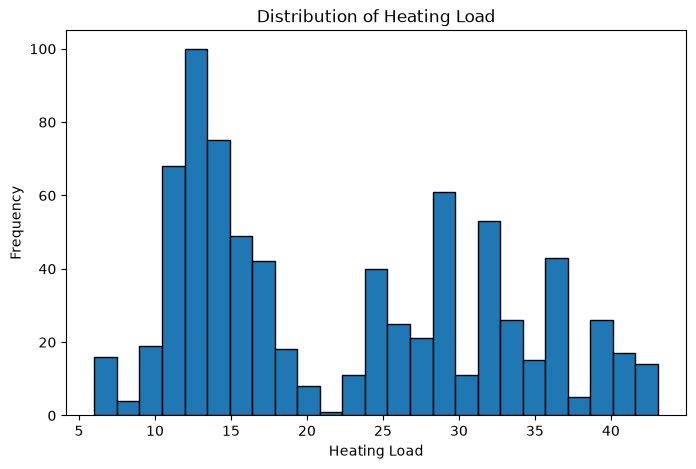

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    y["heating_load"],
    bins=25,
    edgecolor="black",
)

ax.set_title("Distribution of Heating Load")
ax.set_xlabel("Heating Load")
ax.set_ylabel("Frequency")

plt.show()

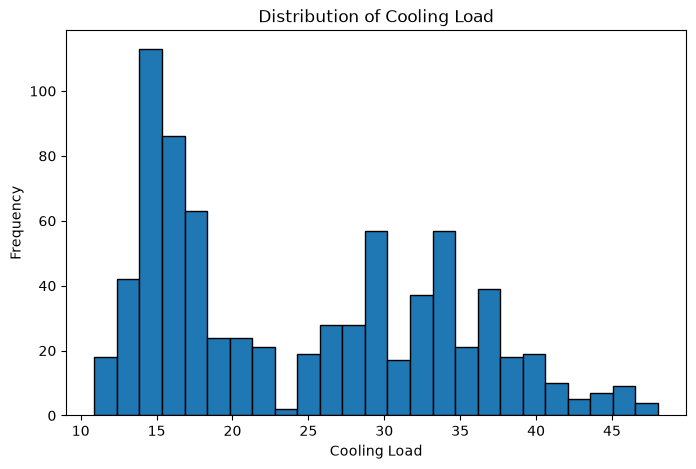

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    y["cooling_load"],
    bins=25,
    edgecolor="black",
)

ax.set_title("Distribution of Cooling Load")
ax.set_xlabel("Cooling Load")
ax.set_ylabel("Frequency")

plt.show()

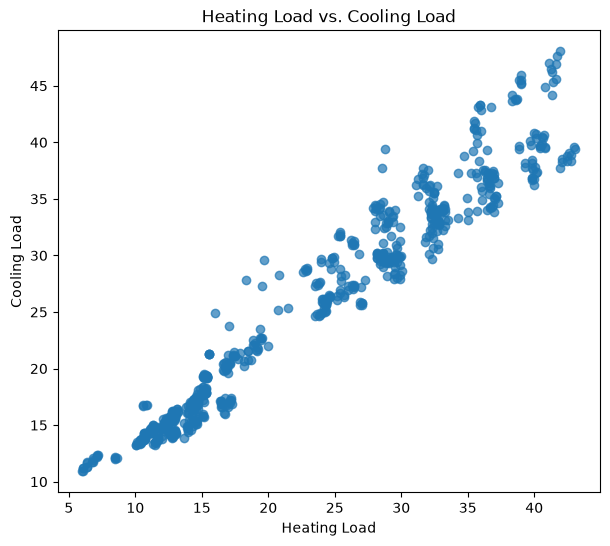

Correlation between Heating Load and Cooling Load: 0.9759


In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    y["heating_load"],
    y["cooling_load"],
    alpha=0.7,
)

ax.set_title("Heating Load vs. Cooling Load")
ax.set_xlabel("Heating Load")
ax.set_ylabel("Cooling Load")

plt.show()

target_correlation = y["heating_load"].corr(y["cooling_load"])

print(f"Correlation between Heating Load and Cooling Load: {target_correlation:.4f}")

In [21]:
eda_data = pd.concat(
    [
        X,
        y["heating_load"],
    ],
    axis=1,
)

correlations = (
    eda_data
    .corr(numeric_only=True)["heating_load"]
    .drop("heating_load")
    .sort_values(key=abs, ascending=False)
)

display(
    correlations.to_frame(name="correlation_with_heating_load")
)

,correlation_with_heating_load
overall_height,0.889431
roof_area,-0.861828
surface_area,-0.658120
relative_compactness,0.622272
wall_area,0.455671
glazing_area,0.269841
glazing_area_distribution,0.087368
orientation,-0.002587


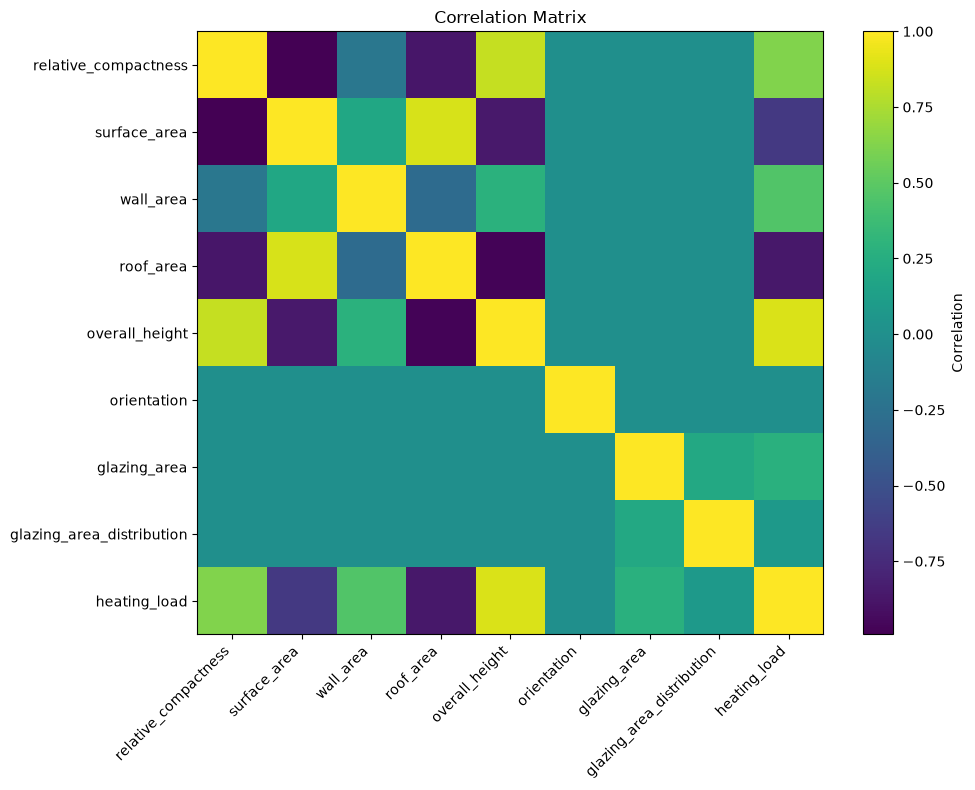

In [22]:
correlation_matrix = eda_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    correlation_matrix,
    aspect="auto",
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(correlation_matrix.columns)

fig.colorbar(image, ax=ax, label="Correlation")

ax.set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

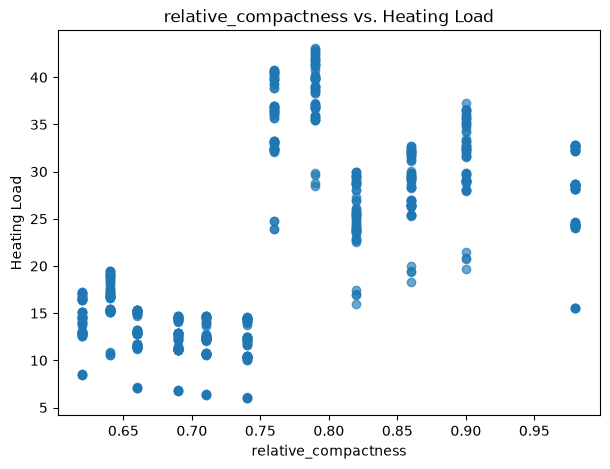

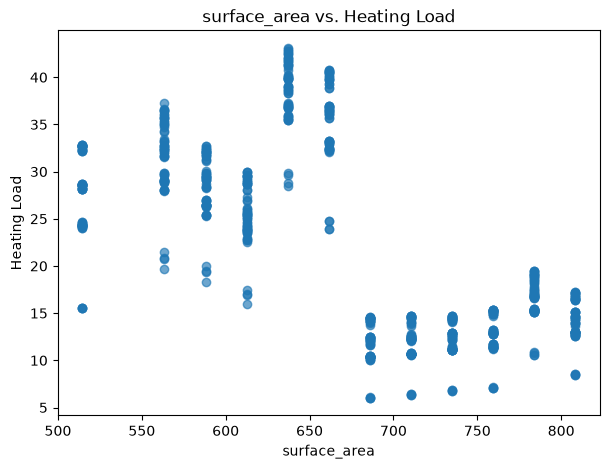

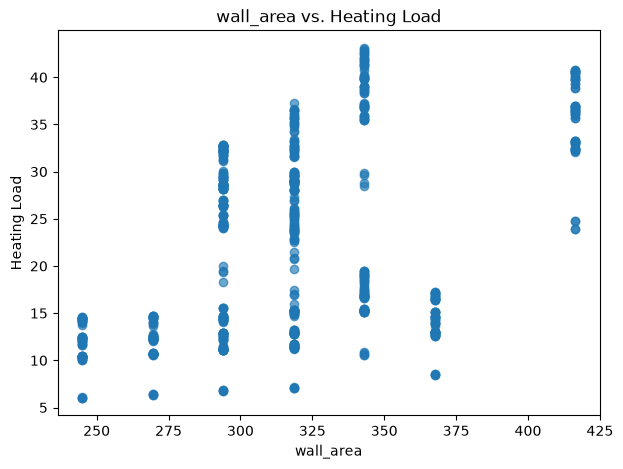

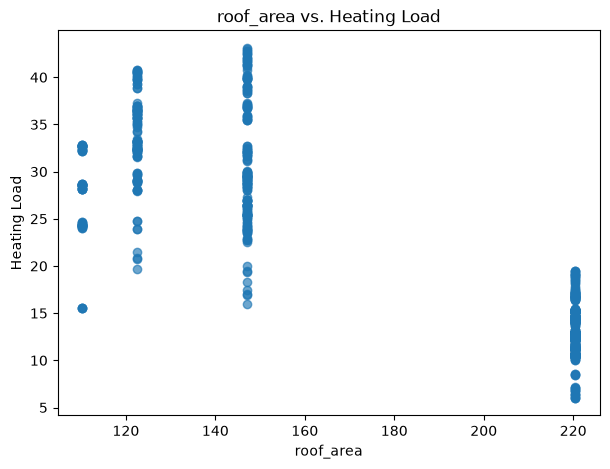

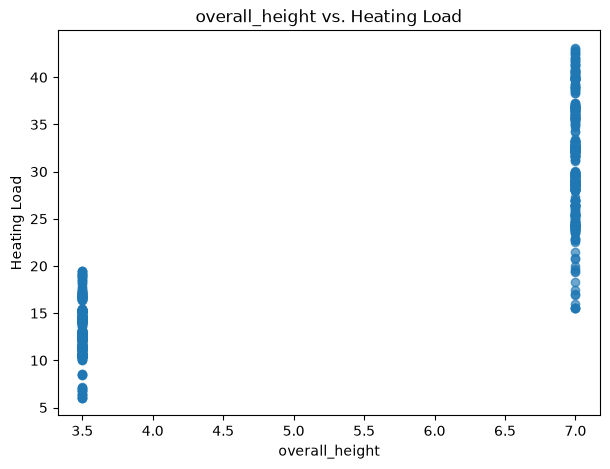

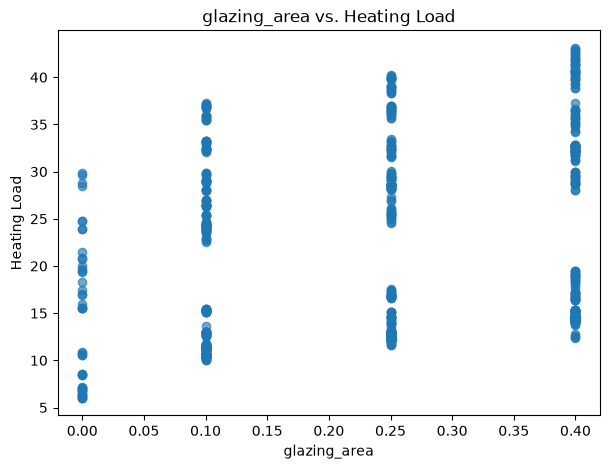

In [23]:
continuous_features = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "glazing_area",
]

for feature in continuous_features:
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(
        X[feature],
        y["heating_load"],
        alpha=0.65,
    )

    ax.set_title(f"{feature} vs. Heating Load")
    ax.set_xlabel(feature)
    ax.set_ylabel("Heating Load")

    plt.show()

,count,mean,median,std
orientation,,,,
2,192,22.312865,19.130,10.108994
3,192,22.380677,19.005,10.140485
4,192,22.259896,18.950,10.119358
5,192,22.275365,18.650,10.070552


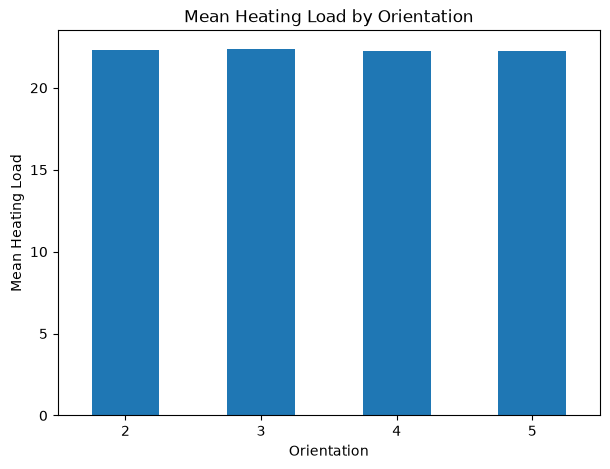

In [24]:
orientation_summary = (
    pd.DataFrame({
        "orientation": X["orientation"],
        "heating_load": y["heating_load"],
    })
    .groupby("orientation")["heating_load"]
    .agg(["count", "mean", "median", "std"])
)

display(orientation_summary)

fig, ax = plt.subplots(figsize=(7, 5))

orientation_summary["mean"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Mean Heating Load by Orientation")
ax.set_xlabel("Orientation")
ax.set_ylabel("Mean Heating Load")

plt.xticks(rotation=0)
plt.show()

,count,mean,median,std
glazing_area_distribution,,,,
0,48,14.286458,13.200,7.625241
1,144,23.026111,21.050,10.031912
2,144,22.934444,20.995,10.053273
3,144,22.681458,20.820,9.990464
4,144,22.886667,20.965,10.064130
5,144,22.680903,20.540,10.051781


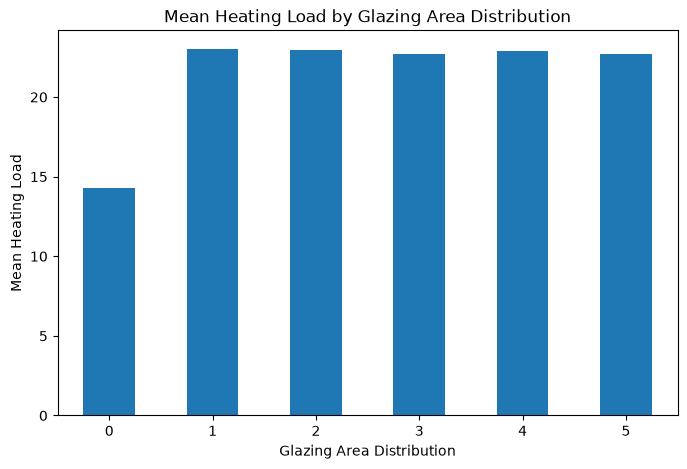

In [25]:
glazing_distribution_summary = (
    pd.DataFrame({
        "glazing_area_distribution": X["glazing_area_distribution"],
        "heating_load": y["heating_load"],
    })
    .groupby("glazing_area_distribution")["heating_load"]
    .agg(["count", "mean", "median", "std"])
)

display(glazing_distribution_summary)

fig, ax = plt.subplots(figsize=(8, 5))

glazing_distribution_summary["mean"].plot(
    kind="bar",
    ax=ax,
)

ax.set_title("Mean Heating Load by Glazing Area Distribution")
ax.set_xlabel("Glazing Area Distribution")
ax.set_ylabel("Mean Heating Load")

plt.xticks(rotation=0)
plt.show()

### Resumo da Análise Exploratória

O conjunto de dados contém **768 observações**, oito variáveis de entrada e dois alvos contínuos (`Heating Load` e `Cooling Load`). Não foram identificados valores ausentes nem registros duplicados nas variáveis de entrada, portanto não será necessário realizar imputação ou remoção de duplicatas nesta etapa.

As variáveis de entrada apresentam escalas bastante distintas, enquanto `relative_compactness` varia entre 0,62 e 0,98, `surface_area` varia entre 514,5 e 808,5 e `wall_area` entre 245,0 e 416,5. Essa diferença de magnitude indica a necessidade de padronização das variáveis numéricas antes do treinamento da MLP, com os parâmetros de transformação calculados exclusivamente a partir do conjunto de treino.

O alvo principal, `Heating Load`, apresenta média de aproximadamente **22,31**, mediana de **18,95**, desvio padrão de **10,09** e valores entre **6,01 e 43,10**. Já `Cooling Load` apresenta média de aproximadamente **24,59**, mediana de **22,08** e valores entre **10,90 e 48,03**. A diferença entre média e mediana, juntamente com a dispersão observada, mostra que a distribuição do alvo não deve ser tratada como uniformemente distribuída.

Os dois alvos possuem uma correlação linear muito forte, de aproximadamente **0,9759**, indicando que edifícios com maior demanda de aquecimento tendem também a apresentar maior demanda de resfriamento. Apesar dessa relação, o projeto utilizará `Heating Load` como alvo principal, mantendo uma única variável de saída para as formulações de regressão e classificação.

Entre as variáveis de entrada, `overall_height` apresentou a maior correlação linear positiva com `Heating Load` (**0,8894**), enquanto `roof_area` apresentou forte correlação negativa (**-0,8618**). Também foram observadas relações relevantes para `surface_area` (**-0,6581**), `relative_compactness` (**0,6223**) e `wall_area` (**0,4557**), oque indica que as características geométricas do edifício possuem forte associação com sua demanda de aquecimento. A correlação, entretanto, mede apenas relações lineares e não determina isoladamente a importância de uma variável para a MLP.

A variável `orientation` possui quatro valores possíveis e apresentou correlação praticamente nula com `Heating Load` (**-0,0026**), e As médias da carga de aquecimento também permaneceram muito próximas entre as quatro orientações, variando aproximadamente entre **22,26 e 22,38**. Isso sugere que a orientação, isoladamente, possui pouca capacidade de explicar a variação do alvo neste conjunto de dados, embora ainda possa contribuir por meio de interações não lineares com outras características.

`Glazing Area Distribution` possui seis valores possíveis, o grupo identificado pelo valor 0 apresentou carga média de aquecimento consideravelmente menor (**14,29**) que os demais grupos, cujas médias permaneceram próximas de **22,7–23,0**. Esse resultado deve ser interpretado com cautela, pois a distribuição do envidraçamento está relacionada a outras características do edifício, especialmente à própria área envidraçada, não sendo adequado atribuir causalidade diretamente a essa variável.

A análise também mostrou que `orientation` e `glazing_area_distribution` são variáveis discretas codificadas numericamente, com quatro e seis valores possíveis, respectivamente. Por representarem categorias e não magnitudes contínuas, seu tratamento será diferenciado durante o pré-processamento, por outro lado, variáveis como `glazing_area` e `overall_height`, embora possuam poucos valores distintos, representam grandezas quantitativas e serão mantidas como variáveis numéricas.

## Preparação dos dados

A partir deste ponto, o conjunto de dados será dividido em treino, validação e teste e será utilizada a proporção de 70% para treino, 15% para validação e 15% para teste, mantendo a mesma divisão para as formulações de classificação e regressão. O conjunto de treino será utilizado para ajustar os parâmetros do pré-processamento e os pesos dos modelos. Já o conjunto de validação será utilizado para comparar configurações, selecionar o melhor checkpoint e orientar decisões de treinamento. E o conjunto de teste permanecerá isolado durante todo o desenvolvimento e será utilizado apenas na avaliação final dos modelos escolhidos.

In [26]:
import shutil

import torch.nn as nn

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from torch.utils.data import DataLoader, TensorDataset

In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
)

print(f"Train samples:      {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")

print(f"\nTrain proportion:      {len(X_train) / len(X):.3f}")
print(f"Validation proportion: {len(X_val) / len(X):.3f}")
print(f"Test proportion:       {len(X_test) / len(X):.3f}")

train_indices = set(X_train.index)
val_indices = set(X_val.index)
test_indices = set(X_test.index)

print("\nOverlap verification:")
print(f"Train ∩ Validation: {len(train_indices & val_indices)}")
print(f"Train ∩ Test:       {len(train_indices & test_indices)}")
print(f"Validation ∩ Test:  {len(val_indices & test_indices)}")

Train samples:      537
Validation samples: 115
Test samples:       116

Train proportion:      0.699
Validation proportion: 0.150
Test proportion:       0.151

Overlap verification:
Train ∩ Validation: 0
Train ∩ Test:       0
Validation ∩ Test:  0


### Formulação do problema de classificação

O alvo original `Heating Load` é contínuo, então para construir a variante de classificação sem introduzir um segundo conjunto de dados, o problema será reformulado como a identificação de edifícios com menor ou maior demanda de aquecimento. O limiar entre as duas classes será definido pela mediana de `Heating Load` calculada exclusivamente no conjunto de treino, onde valores menores ou iguais ao limiar serão associados à classe 0, denominada baixa demanda, enquanto valores acima do limiar serão associados à classe 1, denominada alta demanda.

In [28]:
classification_threshold = y_train["heating_load"].median()

def create_classification_labels(target, threshold):
    return (target["heating_load"] > threshold).astype(np.int64)

y_train_class = create_classification_labels(
    y_train,
    classification_threshold,
)

y_val_class = create_classification_labels(
    y_val,
    classification_threshold,
)

y_test_class = create_classification_labels(
    y_test,
    classification_threshold,
)

print(f"Classification threshold: {classification_threshold:.4f}")

class_distribution = pd.DataFrame({
    "train": y_train_class.value_counts().sort_index(),
    "validation": y_val_class.value_counts().sort_index(),
    "test": y_test_class.value_counts().sort_index(),
}).fillna(0).astype(int)

class_distribution.index = [
    "low_heating_demand",
    "high_heating_demand",
]

display(class_distribution)

class_proportions = class_distribution.div(
    class_distribution.sum(axis=0),
    axis=1,
)

display(class_proportions.round(4))

Classification threshold: 17.2300


,train,validation,test
low_heating_demand,269,43,54
high_heating_demand,268,72,62


,train,validation,test
low_heating_demand,0.5009,0.3739,0.4655
high_heating_demand,0.4991,0.6261,0.5345


### Pré-processamento

A análise exploratória mostrou que as variáveis numéricas possuem escalas bastante diferentes, o que pode fazer com que características de maior magnitude tenham influência desproporcional sobre as atualizações de gradiente. Por esse motivo, as variáveis quantitativas serão padronizadas com média zero e desvio padrão unitário. `orientation` e `glazing_area_distribution` representam categorias codificadas numericamente e, portanto, serão convertidas por One-Hot Encoding e seus valores não devem ser interpretados como uma escala numérica em que uma categoria seja necessariamente maior que outra.

In [29]:
numeric_features = [
    "relative_compactness",
    "surface_area",
    "wall_area",
    "roof_area",
    "overall_height",
    "glazing_area",
]

categorical_features = [
    "orientation",
    "glazing_area_distribution",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32,
)

X_val_processed = np.asarray(
    X_val_processed,
    dtype=np.float32,
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32,
)

processed_feature_names = preprocessor.get_feature_names_out()

print(f"Original feature count:  {X.shape[1]}")
print(f"Processed feature count: {X_train_processed.shape[1]}")

print(f"\nTrain shape:      {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape:       {X_test_processed.shape}")

print("\nProcessed features:")
for feature in processed_feature_names:
    print(f"- {feature}")

numeric_count = len(numeric_features)

print("\nScaled numeric feature means:")
print(
    np.round(
        X_train_processed[:, :numeric_count].mean(axis=0),
        4,
    )
)

print("\nScaled numeric feature standard deviations:")
print(
    np.round(
        X_train_processed[:, :numeric_count].std(axis=0),
        4,
    )
)

Original feature count:  8
Processed feature count: 16

Train shape:      (537, 16)
Validation shape: (115, 16)
Test shape:       (116, 16)

Processed features:
- relative_compactness
- surface_area
- wall_area
- roof_area
- overall_height
- glazing_area
- orientation_2
- orientation_3
- orientation_4
- orientation_5
- glazing_area_distribution_0
- glazing_area_distribution_1
- glazing_area_distribution_2
- glazing_area_distribution_3
- glazing_area_distribution_4
- glazing_area_distribution_5

Scaled numeric feature means:
[-0. -0. -0. -0.  0. -0.]

Scaled numeric feature standard deviations:
[1. 1. 1. 1. 1. 1.]


## Baselines

Antes da construção da MLP, serão utilizados modelos clássicos como referência de desempenho, oque evita avaliar a rede neural de forma isolada e permite verificar se o ganho obtido justifica o aumento de complexidade do modelo. Para classificação será utilizada uma Regressão Logística, enquanto a regressão utilizará Ridge Regression, que constituem baselines treináveis e não triviais, pois aprendem relações entre as características de entrada e o alvo.

In [30]:
classification_baseline = LogisticRegression(
    max_iter=2000,
    random_state=SEED,
)

classification_baseline.fit(
    X_train_processed,
    y_train_class,
)

val_baseline_predictions = classification_baseline.predict(
    X_val_processed,
)

classification_baseline_validation = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall",
        "f1",
    ],
    "value": [
        accuracy_score(
            y_val_class,
            val_baseline_predictions,
        ),
        precision_score(
            y_val_class,
            val_baseline_predictions,
            zero_division=0,
        ),
        recall_score(
            y_val_class,
            val_baseline_predictions,
            zero_division=0,
        ),
        f1_score(
            y_val_class,
            val_baseline_predictions,
            zero_division=0,
        ),
    ],
})

display(classification_baseline_validation)

,metric,value
0,accuracy,0.956522
1,precision,0.985507
2,recall,0.944444
3,f1,0.964539


In [31]:
regression_baseline = Ridge(
    alpha=1.0,
)

regression_baseline.fit(
    X_train_processed,
    y_train["heating_load"],
)

val_regression_baseline_predictions = regression_baseline.predict(
    X_val_processed,
)

baseline_val_mae = mean_absolute_error(
    y_val["heating_load"],
    val_regression_baseline_predictions,
)

baseline_val_rmse = np.sqrt(
    mean_squared_error(
        y_val["heating_load"],
        val_regression_baseline_predictions,
    )
)

baseline_val_r2 = r2_score(
    y_val["heating_load"],
    val_regression_baseline_predictions,
)

regression_baseline_validation = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE",
        "R²",
    ],
    "value": [
        baseline_val_mae,
        baseline_val_rmse,
        baseline_val_r2,
    ],
})

display(regression_baseline_validation)

,metric,value
0,MAE,2.268689
1,RMSE,3.094646
2,R²,0.906307


## Conversão para PyTorch e DataLoaders

Após o pré-processamento, os dados serão convertidos para tensores do PyTorch e a classificação utilizará rótulos inteiros porque a função `CrossEntropyLoss` espera índices de classe, enquanto a regressão utiliza valores de ponto flutuante para representar diretamente `Heating Load`. O treinamento será realizado em mini-batches com `DataLoader`, apenas o conjunto de treino será embaralhado, pois a ordem das amostras deve variar durante a otimização. A validação e teste permanecerão em ordem fixa, uma vez que nenhum peso é atualizado durante essas etapas.

In [32]:
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32,
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32,
)

y_train_class_tensor = torch.tensor(
    y_train_class.to_numpy(),
    dtype=torch.long,
)

y_val_class_tensor = torch.tensor(
    y_val_class.to_numpy(),
    dtype=torch.long,
)

y_test_class_tensor = torch.tensor(
    y_test_class.to_numpy(),
    dtype=torch.long,
)

y_train_reg_tensor = torch.tensor(
    y_train["heating_load"].to_numpy(),
    dtype=torch.float32,
).view(-1, 1)

y_val_reg_tensor = torch.tensor(
    y_val["heating_load"].to_numpy(),
    dtype=torch.float32,
).view(-1, 1)

y_test_reg_tensor = torch.tensor(
    y_test["heating_load"].to_numpy(),
    dtype=torch.float32,
).view(-1, 1)

classification_datasets = {
    "train": TensorDataset(
        X_train_tensor,
        y_train_class_tensor,
    ),
    "validation": TensorDataset(
        X_val_tensor,
        y_val_class_tensor,
    ),
    "test": TensorDataset(
        X_test_tensor,
        y_test_class_tensor,
    ),
}

regression_datasets = {
    "train": TensorDataset(
        X_train_tensor,
        y_train_reg_tensor,
    ),
    "validation": TensorDataset(
        X_val_tensor,
        y_val_reg_tensor,
    ),
    "test": TensorDataset(
        X_test_tensor,
        y_test_reg_tensor,
    ),
}

BATCH_SIZE = 32

def create_dataloaders(task, seed=SEED):
    if task == "classification":
        datasets = classification_datasets
    elif task == "regression":
        datasets = regression_datasets
    else:
        raise ValueError(
            "Task must be 'classification' or 'regression'."
        )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    val_loader = DataLoader(
        datasets["validation"],
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_loader = DataLoader(
        datasets["test"],
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_dataloaders(
    "classification"
)

features_batch, labels_batch = next(iter(train_loader))

print(f"Feature batch shape: {features_batch.shape}")
print(f"Label batch shape:   {labels_batch.shape}")
print(f"Feature dtype:       {features_batch.dtype}")
print(f"Label dtype:         {labels_batch.dtype}")

Feature batch shape: torch.Size([32, 16])
Label batch shape:   torch.Size([32])
Feature dtype:       torch.float32
Label dtype:         torch.int64


## Arquitetura da MLP

A arquitetura inicial será composta por duas camadas ocultas com 64 e 32 neurônios. o conjunto de dados possui apenas 768 observações e um número reduzido de características após o pré-processamento, portanto uma rede excessivamente profunda ou larga aumentaria a capacidade do modelo sem uma justificativa proporcional à complexidade do problema e poderia favorecer overfitting.

A primeira camada oculta expande a representação de entrada para 64 unidades, permitindo aprender combinações não lineares entre as características arquitetônicas. Já a segunda reduz essa representação para 32 unidades antes da saída, funcionando como uma compressão gradual das características aprendidas.

A mesma estrutura será reutilizada nas formulações de classificação e regressão. Na classificação, a camada final produzirá dois logits, um para cada classe e na regressão, produzirá um único valor contínuo. A implementação utiliza `nn.Module`, com cada camada e o `forward` declarados explicitamente para manter visível o fluxo de dados pela rede.

In [33]:
class EnergyMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        activation_name="relu",
        use_batch_norm=False,
        dropout_rate=0.0,
        initialization="default",
    ):
        super().__init__()

        self.activation_name = activation_name
        self.use_batch_norm = use_batch_norm
        self.dropout_rate = dropout_rate
        self.initialization = initialization

        self.fc1 = nn.Linear(
            input_dim,
            64,
        )

        self.bn1 = (
            nn.BatchNorm1d(64)
            if use_batch_norm
            else nn.Identity()
        )

        self.activation1 = self._create_activation(
            activation_name
        )

        self.dropout1 = nn.Dropout(
            p=dropout_rate
        )

        self.fc2 = nn.Linear(
            64,
            32,
        )

        self.bn2 = (
            nn.BatchNorm1d(32)
            if use_batch_norm
            else nn.Identity()
        )

        self.activation2 = self._create_activation(
            activation_name
        )

        self.dropout2 = nn.Dropout(
            p=dropout_rate
        )

        self.output = nn.Linear(
            32,
            output_dim,
        )

        if initialization == "he":
            self._apply_he_initialization()
        elif initialization != "default":
            raise ValueError(
                "Initialization must be 'default' or 'he'."
            )

    def _create_activation(self, activation_name):
        if activation_name == "relu":
            return nn.ReLU()

        if activation_name == "tanh":
            return nn.Tanh()

        raise ValueError(
            "Activation must be 'relu' or 'tanh'."
        )

    def _apply_he_initialization(self):
        nn.init.kaiming_normal_(
            self.fc1.weight,
            mode="fan_in",
            nonlinearity="relu",
        )

        nn.init.zeros_(
            self.fc1.bias
        )

        nn.init.kaiming_normal_(
            self.fc2.weight,
            mode="fan_in",
            nonlinearity="relu",
        )

        nn.init.zeros_(
            self.fc2.bias
        )

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.dropout2(x)

        x = self.output(x)

        return x


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


INPUT_DIM = X_train_processed.shape[1]

classification_model_example = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

print(classification_model_example)

print(
    f"\nTrainable parameters: "
    f"{count_trainable_parameters(classification_model_example):,}"
)

EnergyMLP(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (bn1): Identity()
  (activation1): ReLU()
  (dropout1): Dropout(p=0.0, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): Identity()
  (activation2): ReLU()
  (dropout2): Dropout(p=0.0, inplace=False)
  (output): Linear(in_features=32, out_features=2, bias=True)
)

Trainable parameters: 3,234


### Fluxo de treinamento

Em cada mini-batch, o treinamento segue explicitamente o ciclo `forward → loss → backward → step`. Primeiro, as entradas passam pelo método `forward`, produzindo a predição atual da rede, a função de perda mede a diferença entre essa predição e o alvo correto e em seguida, `backward()` aplica backpropagation e calcula os gradientes da perda em relação aos parâmetros treináveis.

Os gradient norms são medidos depois de `backward()` e antes de `optimizer.step()`, momento em que os gradientes correspondem exatamente à atualização que está prestes a ser aplicada. Por fim, o otimizador modifica os pesos na direção indicada por esses gradientes e antes do próximo mini-batch, os gradientes anteriores são zerados para que não sejam acumulados indevidamente.

In [34]:
def reset_random_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def compute_gradient_norms(model):
    total_squared_norm = 0.0

    tracked_layers = {
        "fc1.weight": 0.0,
        "fc2.weight": 0.0,
        "output.weight": 0.0,
    }

    for name, parameter in model.named_parameters():
        if parameter.grad is None:
            continue

        parameter_norm = parameter.grad.detach().norm(
            p=2
        ).item()

        total_squared_norm += parameter_norm ** 2

        if name in tracked_layers:
            tracked_layers[name] = parameter_norm

    global_norm = total_squared_norm ** 0.5

    return global_norm, tracked_layers


def evaluate_classifier(
    model,
    loader,
    criterion,
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(features)

            loss = criterion(
                logits,
                targets,
            )

            predictions = logits.argmax(
                dim=1
            )

            batch_size = features.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    average_loss = (
        running_loss
        / total_samples
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions,
    )

    precision = precision_score(
        all_targets,
        all_predictions,
        zero_division=0,
    )

    recall = recall_score(
        all_targets,
        all_predictions,
        zero_division=0,
    )

    f1 = f1_score(
        all_targets,
        all_predictions,
        zero_division=0,
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def train_classifier(
    model,
    experiment_name,
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=False,
    early_stopping_patience=30,
):
    reset_random_seeds()

    train_loader, val_loader, _ = create_dataloaders(
        "classification"
    )

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = None

    if use_scheduler:
        scheduler = (
            torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=8,
                min_lr=1e-6,
            )
        )

    run_dir = (
        RUNS_DIR
        / "project_1"
        / "classification"
        / experiment_name
    )

    if run_dir.exists():
        shutil.rmtree(run_dir)

    writer = SummaryWriter(
        log_dir=run_dir
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"classification_{experiment_name}_best.pt"
    )

    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    history = []

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        running_train_loss = 0.0
        total_train_samples = 0
        correct_train_predictions = 0

        global_gradient_norms = []

        layer_gradient_norms = {
            "fc1.weight": [],
            "fc2.weight": [],
            "output.weight": [],
        }

        for features, targets in train_loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(features)

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()

            global_norm, layer_norms = (
                compute_gradient_norms(model)
            )

            global_gradient_norms.append(
                global_norm
            )

            for layer_name, layer_norm in (
                layer_norms.items()
            ):
                layer_gradient_norms[
                    layer_name
                ].append(layer_norm)

            optimizer.step()

            predictions = logits.argmax(
                dim=1
            )

            batch_size = features.size(0)

            running_train_loss += (
                loss.item()
                * batch_size
            )

            total_train_samples += batch_size

            correct_train_predictions += (
                predictions == targets
            ).sum().item()

        train_loss = (
            running_train_loss
            / total_train_samples
        )

        train_accuracy = (
            correct_train_predictions
            / total_train_samples
        )

        validation_metrics = (
            evaluate_classifier(
                model,
                val_loader,
                criterion,
            )
        )

        val_loss = validation_metrics["loss"]

        if scheduler is not None:
            scheduler.step(
                val_loss
            )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        mean_global_gradient_norm = float(
            np.mean(
                global_gradient_norms
            )
        )

        max_global_gradient_norm = float(
            np.max(
                global_gradient_norms
            )
        )

        mean_fc1_gradient_norm = float(
            np.mean(
                layer_gradient_norms[
                    "fc1.weight"
                ]
            )
        )

        mean_fc2_gradient_norm = float(
            np.mean(
                layer_gradient_norms[
                    "fc2.weight"
                ]
            )
        )

        mean_output_gradient_norm = float(
            np.mean(
                layer_gradient_norms[
                    "output.weight"
                ]
            )
        )

        loss_gap = (
            val_loss
            - train_loss
        )

        writer.add_scalars(
            "Loss",
            {
                "train": train_loss,
                "validation": val_loss,
            },
            epoch,
        )

        writer.add_scalars(
            "Accuracy",
            {
                "train": train_accuracy,
                "validation": validation_metrics[
                    "accuracy"
                ],
            },
            epoch,
        )

        writer.add_scalar(
            "F1/validation",
            validation_metrics["f1"],
            epoch,
        )

        writer.add_scalar(
            "LearningRate",
            current_learning_rate,
            epoch,
        )

        writer.add_scalar(
            "Gap/validation_minus_train_loss",
            loss_gap,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_mean",
            mean_global_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_max",
            max_global_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/fc1",
            mean_fc1_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/fc2",
            mean_fc2_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/output",
            mean_output_gradient_norm,
            epoch,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_accuracy,
            "val_accuracy": validation_metrics[
                "accuracy"
            ],
            "val_precision": validation_metrics[
                "precision"
            ],
            "val_recall": validation_metrics[
                "recall"
            ],
            "val_f1": validation_metrics[
                "f1"
            ],
            "loss_gap": loss_gap,
            "learning_rate": current_learning_rate,
            "grad_global_mean": (
                mean_global_gradient_norm
            ),
            "grad_global_max": (
                max_global_gradient_norm
            ),
            "grad_fc1": (
                mean_fc1_gradient_norm
            ),
            "grad_fc2": (
                mean_fc2_gradient_norm
            ),
            "grad_output": (
                mean_output_gradient_norm
            ),
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 25 == 0
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val F1: "
                f"{validation_metrics['f1']:.4f} | "
                f"Grad Norm: "
                f"{mean_global_gradient_norm:.4f} | "
                f"LR: "
                f"{current_learning_rate:.6f}"
            )

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                f"Early stopping at epoch "
                f"{epoch}."
            )
            break

    writer.close()

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True,
        )
    )

    best_validation_metrics = (
        evaluate_classifier(
            model,
            val_loader,
            criterion,
        )
    )

    print(
        f"\nBest epoch: {best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )

    print(
        f"Best validation F1: "
        f"{best_validation_metrics['f1']:.4f}"
    )

    return (
        model,
        pd.DataFrame(history),
        checkpoint_path,
        best_validation_metrics,
    )

## Experimentos de classificação

O primeiro experimento estabelece a referência neural para as comparações posteriores, a MLP utilizará ReLU, inicialização padrão do PyTorch, sem BatchNorm, sem Dropout e sem learning rate scheduler, essa configuração será denominada `C01`.

In [35]:
reset_random_seeds()

c01_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

(
    c01_model,
    c01_history,
    c01_checkpoint,
    c01_validation_metrics,
) = train_classifier(
    model=c01_model,
    experiment_name="c01_relu_default",
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=False,
    early_stopping_patience=30,
)

display(
    c01_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{c01_checkpoint}"
)

print(
    "\nValidation metrics:"
)

for metric_name, metric_value in (
    c01_validation_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Epoch 001 | Train Loss: 0.6222 | Val Loss: 0.5170 | Val F1: 0.9645 | Grad Norm: 0.4600 | LR: 0.001000
Epoch 025 | Train Loss: 0.0664 | Val Loss: 0.0995 | Val F1: 0.9583 | Grad Norm: 0.3283 | LR: 0.001000
Epoch 050 | Train Loss: 0.0318 | Val Loss: 0.0807 | Val F1: 0.9650 | Grad Norm: 0.2509 | LR: 0.001000
Epoch 075 | Train Loss: 0.0140 | Val Loss: 0.0674 | Val F1: 0.9722 | Grad Norm: 0.2147 | LR: 0.001000
Epoch 100 | Train Loss: 0.0056 | Val Loss: 0.0574 | Val F1: 0.9861 | Grad Norm: 0.1319 | LR: 0.001000
Epoch 125 | Train Loss: 0.0024 | Val Loss: 0.0535 | Val F1: 0.9861 | Grad Norm: 0.0756 | LR: 0.001000
Epoch 150 | Train Loss: 0.0013 | Val Loss: 0.0533 | Val F1: 0.9861 | Grad Norm: 0.0469 | LR: 0.001000
Early stopping at epoch 171.

Best epoch: 141
Best validation loss: 0.0517
Best validation F1: 0.9861


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,loss_gap,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
166,167,0.000891,0.054533,1.0,0.982609,0.986111,0.986111,0.986111,0.053642,0.001,0.035130,0.124149,0.032295,0.007579,0.003300
167,168,0.000869,0.055247,1.0,0.982609,0.986111,0.986111,0.986111,0.054378,0.001,0.030274,0.106485,0.027498,0.007214,0.003421
168,169,0.000775,0.054803,1.0,0.982609,0.986111,0.986111,0.986111,0.054027,0.001,0.028288,0.071207,0.025979,0.005937,0.002745
169,170,0.000770,0.054410,1.0,0.982609,0.986111,0.986111,0.986111,0.053640,0.001,0.028328,0.092801,0.026050,0.005109,0.002534
170,171,0.000739,0.055495,1.0,0.982609,0.986111,0.986111,0.986111,0.054756,0.001,0.022212,0.058333,0.020072,0.004984,0.002609



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c01_relu_default_best.pt

Validation metrics:
loss: 0.0517
accuracy: 0.9826
precision: 0.9861
recall: 0.9861
f1: 0.9861


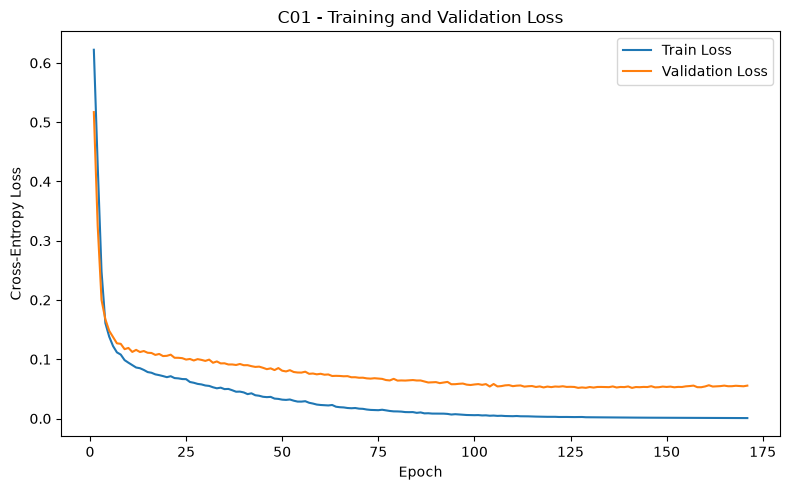

In [36]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    c01_history["epoch"],
    c01_history["train_loss"],
    label="Train Loss",
)

ax.plot(
    c01_history["epoch"],
    c01_history["val_loss"],
    label="Validation Loss",
)

ax.set_title(
    "C01 - Training and Validation Loss"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Cross-Entropy Loss"
)

ax.legend()

plt.tight_layout()
plt.show()

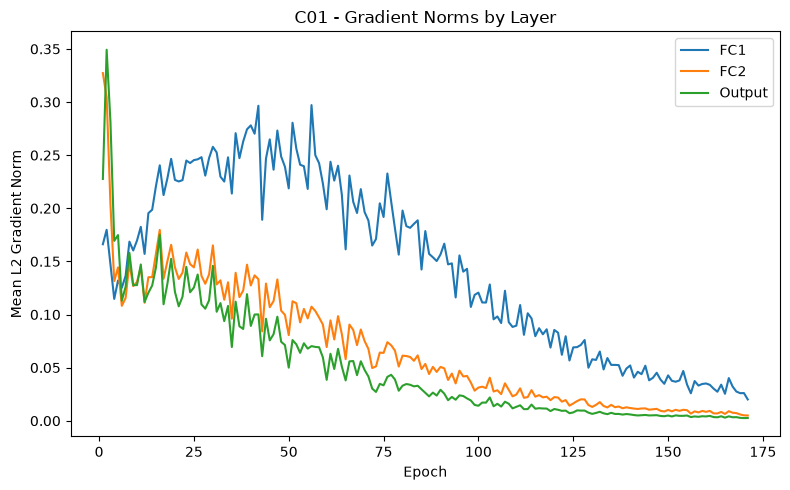

In [37]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    c01_history["epoch"],
    c01_history["grad_fc1"],
    label="FC1",
)

ax.plot(
    c01_history["epoch"],
    c01_history["grad_fc2"],
    label="FC2",
)

ax.plot(
    c01_history["epoch"],
    c01_history["grad_output"],
    label="Output",
)

ax.set_title(
    "C01 - Gradient Norms by Layer"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Mean L2 Gradient Norm"
)

ax.legend()

plt.tight_layout()
plt.show()

### C02 — Comparação da função de ativação

O segundo experimento altera apenas a função de ativação da MLP, substituindo ReLU por Tanh. A arquitetura, a inicialização padrão do PyTorch, o otimizador, o learning rate, o weight decay e a ausência de BatchNorm, Dropout e scheduler permanecem iguais ao experimento C01. Essa comparação permitirá avaliar empiricamente não apenas o desempenho de validação, mas também o efeito da ativação sobre o fluxo de gradientes, a Tanh produz valores limitados ao intervalo entre -1 e 1 e pode apresentar saturação quando suas entradas possuem magnitude elevada, reduzindo os gradientes propagados para camadas anteriores.

In [38]:
reset_random_seeds()

c02_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="tanh",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

(
    c02_model,
    c02_history,
    c02_checkpoint,
    c02_validation_metrics,
) = train_classifier(
    model=c02_model,
    experiment_name="c02_tanh_default",
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=False,
    early_stopping_patience=30,
)

display(c02_history.tail())

print(f"\nCheckpoint: {c02_checkpoint}")

print("\nValidation metrics:")

for metric_name, metric_value in c02_validation_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Epoch 001 | Train Loss: 0.5115 | Val Loss: 0.3353 | Val F1: 0.9645 | Grad Norm: 0.8258 | LR: 0.001000
Epoch 025 | Train Loss: 0.0847 | Val Loss: 0.1162 | Val F1: 0.9577 | Grad Norm: 0.2889 | LR: 0.001000
Epoch 050 | Train Loss: 0.0728 | Val Loss: 0.1103 | Val F1: 0.9510 | Grad Norm: 0.2598 | LR: 0.001000
Epoch 075 | Train Loss: 0.0659 | Val Loss: 0.1032 | Val F1: 0.9577 | Grad Norm: 0.3067 | LR: 0.001000
Epoch 100 | Train Loss: 0.0584 | Val Loss: 0.1026 | Val F1: 0.9577 | Grad Norm: 0.2945 | LR: 0.001000
Epoch 125 | Train Loss: 0.0436 | Val Loss: 0.0934 | Val F1: 0.9577 | Grad Norm: 0.3163 | LR: 0.001000
Epoch 150 | Train Loss: 0.0242 | Val Loss: 0.0622 | Val F1: 0.9722 | Grad Norm: 0.2596 | LR: 0.001000
Epoch 175 | Train Loss: 0.0103 | Val Loss: 0.0433 | Val F1: 0.9859 | Grad Norm: 0.1744 | LR: 0.001000
Epoch 200 | Train Loss: 0.0048 | Val Loss: 0.0337 | Val F1: 0.9859 | Grad Norm: 0.0816 | LR: 0.001000

Best epoch: 199
Best validation loss: 0.0335
Best validation F1: 0.9859


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,loss_gap,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
195,196,0.005368,0.034191,1.0,0.991304,1.0,0.986111,0.993007,0.028823,0.001,0.096119,0.266341,0.081781,0.034403,0.015984
196,197,0.005076,0.037285,1.0,0.982609,1.0,0.972222,0.985915,0.032209,0.001,0.074854,0.249660,0.065056,0.026978,0.012849
197,198,0.005009,0.036671,1.0,0.982609,1.0,0.972222,0.985915,0.031662,0.001,0.084613,0.186468,0.073670,0.031051,0.014983
198,199,0.005105,0.033506,1.0,0.982609,1.0,0.972222,0.985915,0.028401,0.001,0.104462,0.342404,0.091617,0.037541,0.017710
199,200,0.004779,0.033656,1.0,0.982609,1.0,0.972222,0.985915,0.028877,0.001,0.081555,0.181349,0.070388,0.029478,0.013636



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c02_tanh_default_best.pt

Validation metrics:
loss: 0.0335
accuracy: 0.9826
precision: 1.0000
recall: 0.9722
f1: 0.9859


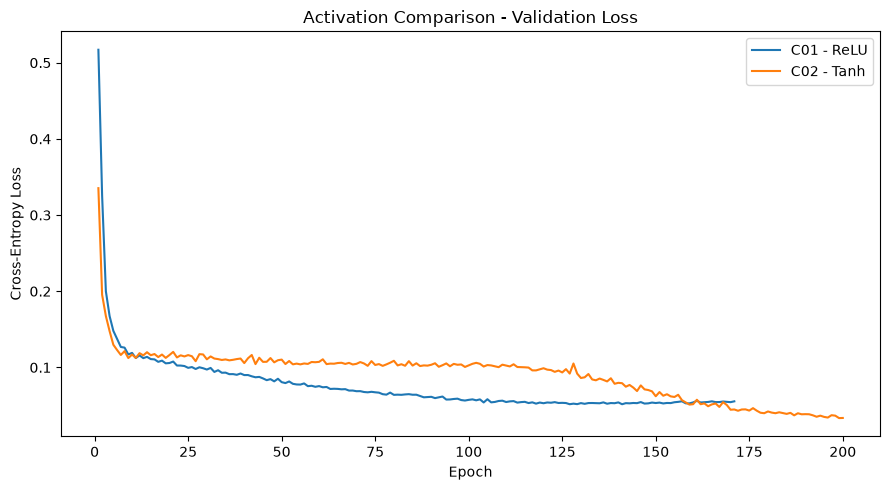

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["val_loss"],
    label="C01 - ReLU",
)

ax.plot(
    c02_history["epoch"],
    c02_history["val_loss"],
    label="C02 - Tanh",
)

ax.set_title(
    "Activation Comparison - Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()

plt.tight_layout()
plt.show()

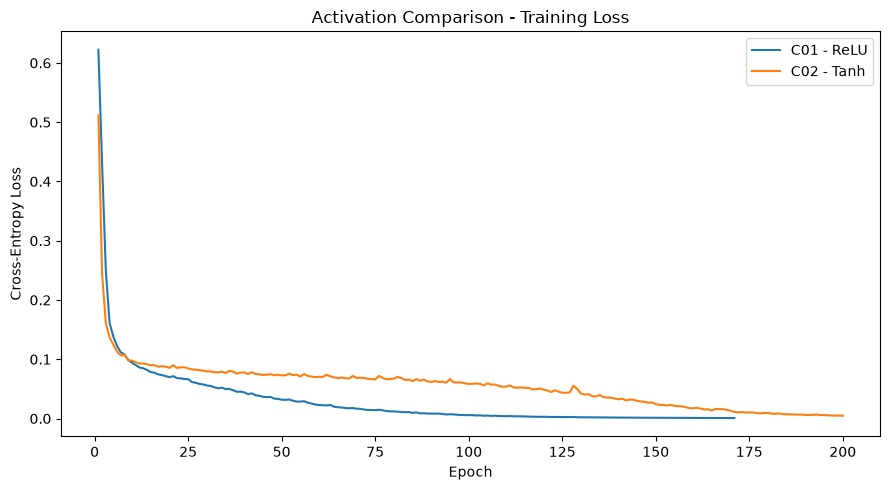

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["train_loss"],
    label="C01 - ReLU",
)

ax.plot(
    c02_history["epoch"],
    c02_history["train_loss"],
    label="C02 - Tanh",
)

ax.set_title(
    "Activation Comparison - Training Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()

plt.tight_layout()
plt.show()

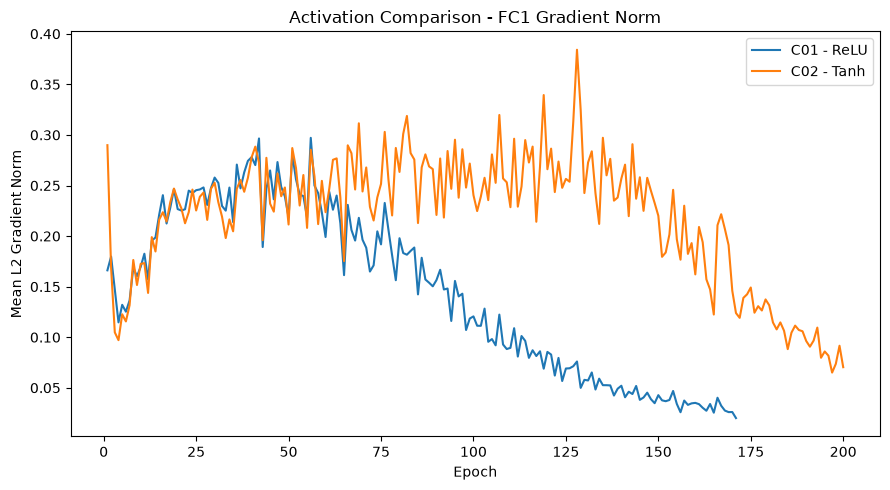

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["grad_fc1"],
    label="C01 - ReLU",
)

ax.plot(
    c02_history["epoch"],
    c02_history["grad_fc1"],
    label="C02 - Tanh",
)

ax.set_title(
    "Activation Comparison - FC1 Gradient Norm"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")
ax.legend()

plt.tight_layout()
plt.show()

In [42]:
def summarize_classification_experiment(
    experiment_name,
    history,
    validation_metrics,
):
    best_index = history["val_loss"].idxmin()
    best_row = history.loc[best_index]

    return {
        "experiment": experiment_name,
        "best_epoch": int(best_row["epoch"]),
        "best_val_loss": best_row["val_loss"],
        "val_accuracy": validation_metrics["accuracy"],
        "val_f1": validation_metrics["f1"],
        "final_train_loss": history.iloc[-1]["train_loss"],
        "final_val_loss": history.iloc[-1]["val_loss"],
        "final_loss_gap": history.iloc[-1]["loss_gap"],
        "initial_global_grad": history.iloc[0]["grad_global_mean"],
        "final_global_grad": history.iloc[-1]["grad_global_mean"],
        "initial_fc1_grad": history.iloc[0]["grad_fc1"],
        "final_fc1_grad": history.iloc[-1]["grad_fc1"],
    }


activation_comparison = pd.DataFrame([
    summarize_classification_experiment(
        "C01 - ReLU",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_classification_experiment(
        "C02 - Tanh",
        c02_history,
        c02_validation_metrics,
    ),
])

display(
    activation_comparison.round(6)
)

,experiment,best_epoch,best_val_loss,val_accuracy,val_f1,final_train_loss,final_val_loss,final_loss_gap,initial_global_grad,final_global_grad,initial_fc1_grad,final_fc1_grad
0,C01 - ReLU,141,0.051682,0.982609,0.986111,0.000739,0.055495,0.054756,0.459977,0.022212,0.166152,0.020072
1,C02 - Tanh,199,0.033506,0.982609,0.985915,0.004779,0.033656,0.028877,0.825765,0.081555,0.289878,0.070388


### C03 — Inicialização He

Após a comparação das funções de ativação, o terceiro experimento retorna à ReLU e altera somente a estratégia de inicialização das camadas ocultas, em vez da inicialização padrão utilizada pelo PyTorch, os pesos de `fc1` e `fc2` serão inicializados com o método de He, também conhecido como Kaiming initialization. A inicialização He considera o número de entradas de cada camada e foi proposta para redes que utilizam ativações como ReLU, buscando preservar melhor a variância das ativações e dos gradientes durante sua propagação pela rede, as camadas ocultas recebem essa inicialização porque são seguidas por ReLU e a camada de saída permanece com a inicialização padrão, já que produz diretamente os logits e não é seguida pela mesma função de ativação.

In [43]:
reset_random_seeds()

c03_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="he",
)

(
    c03_model,
    c03_history,
    c03_checkpoint,
    c03_validation_metrics,
) = train_classifier(
    model=c03_model,
    experiment_name="c03_relu_he",
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=False,
    early_stopping_patience=30,
)

display(c03_history.tail())

print(f"\nCheckpoint: {c03_checkpoint}")

print("\nValidation metrics:")

for metric_name, metric_value in c03_validation_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Epoch 001 | Train Loss: 0.6466 | Val Loss: 0.4143 | Val F1: 0.9517 | Grad Norm: 1.3629 | LR: 0.001000
Epoch 025 | Train Loss: 0.0600 | Val Loss: 0.1046 | Val F1: 0.9650 | Grad Norm: 0.3064 | LR: 0.001000
Epoch 050 | Train Loss: 0.0358 | Val Loss: 0.1096 | Val F1: 0.9650 | Grad Norm: 0.2291 | LR: 0.001000
Early stopping at epoch 52.

Best epoch: 22
Best validation loss: 0.1026
Best validation F1: 0.9650


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,loss_gap,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
47,48,0.036710,0.105598,0.986965,0.956522,0.971831,0.958333,0.965035,0.068887,0.001,0.270718,0.559229,0.150298,0.154119,0.147233
48,49,0.036891,0.114503,0.986965,0.947826,0.971429,0.944444,0.957746,0.077612,0.001,0.264493,0.620926,0.150500,0.149731,0.142369
49,50,0.035842,0.109599,0.985102,0.956522,0.971831,0.958333,0.965035,0.073757,0.001,0.229118,0.664224,0.138479,0.130878,0.115120
50,51,0.034788,0.110969,0.986965,0.947826,0.971429,0.944444,0.957746,0.076181,0.001,0.280279,0.528076,0.162549,0.158912,0.148924
51,52,0.035160,0.112491,0.985102,0.947826,0.971429,0.944444,0.957746,0.077331,0.001,0.249853,0.631894,0.146343,0.140888,0.131158



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c03_relu_he_best.pt

Validation metrics:
loss: 0.1026
accuracy: 0.9565
precision: 0.9718
recall: 0.9583
f1: 0.9650


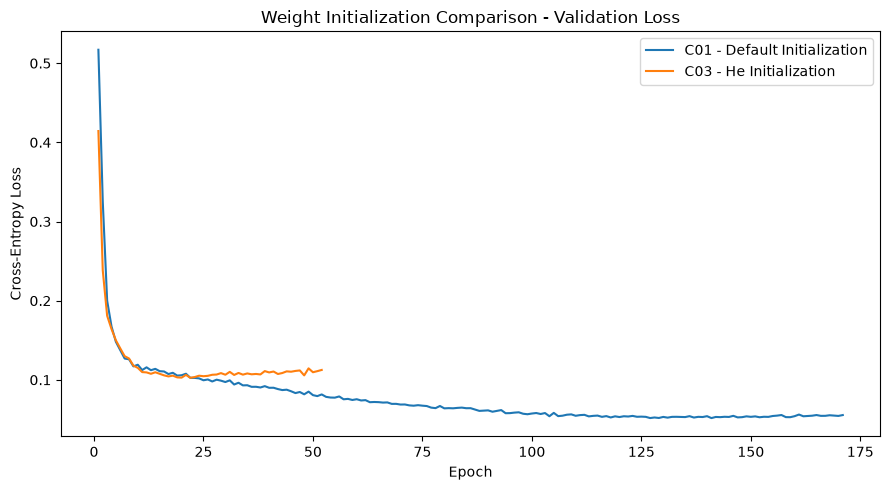

In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["val_loss"],
    label="C01 - Default Initialization",
)

ax.plot(
    c03_history["epoch"],
    c03_history["val_loss"],
    label="C03 - He Initialization",
)

ax.set_title(
    "Weight Initialization Comparison - Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()

plt.tight_layout()
plt.show()

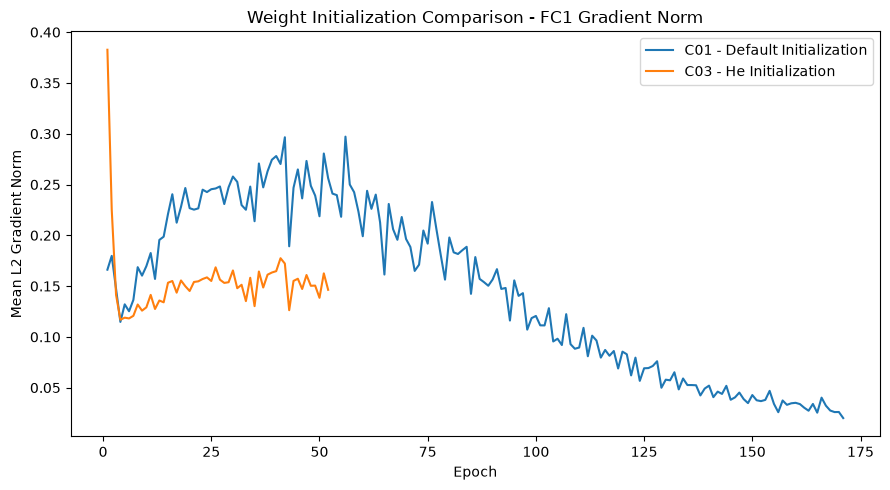

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["grad_fc1"],
    label="C01 - Default Initialization",
)

ax.plot(
    c03_history["epoch"],
    c03_history["grad_fc1"],
    label="C03 - He Initialization",
)

ax.set_title(
    "Weight Initialization Comparison - FC1 Gradient Norm"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")
ax.legend()

plt.tight_layout()
plt.show()

In [46]:
initialization_comparison = pd.DataFrame([
    summarize_classification_experiment(
        "C01 - Default",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_classification_experiment(
        "C03 - He",
        c03_history,
        c03_validation_metrics,
    ),
])

display(
    initialization_comparison.round(6)
)

,experiment,best_epoch,best_val_loss,val_accuracy,val_f1,final_train_loss,final_val_loss,final_loss_gap,initial_global_grad,final_global_grad,initial_fc1_grad,final_fc1_grad
0,C01 - Default,141,0.051682,0.982609,0.986111,0.000739,0.055495,0.054756,0.459977,0.022212,0.166152,0.020072
1,C03 - He,22,0.102585,0.956522,0.965035,0.035160,0.112491,0.077331,1.362909,0.249853,0.382675,0.146343


### Análise dos experimentos de ativação e inicialização

A comparação entre C01 e C02 mostrou que a mudança de ReLU para Tanh alterou de forma perceptível a dinâmica do treinamento, mas praticamente não modificou o desempenho final de classificação. A configuração com ReLU alcançou `val_loss` mínima de aproximadamente 0,0517 e F1 de 0,9861 na época 141, enquanto a Tanh atingiu `val_loss` menor, de aproximadamente 0,0335, e F1 de 0,9859, alcançando seu melhor resultado apenas na época 199. Assim, a Tanh apresentou convergência mais lenta, porém terminou com uma função de perda de validação menor e desempenho classificatório praticamente equivalente.

A análise dos gradientes não mostrou vanishing gradients com Tanh nesta arquitetura, o gradient norm global inicial foi maior em C02 do que em C01, assim como a norma observada na primeira camada e os gradientes também permaneceram maiores ao final do treinamento. Portanto, embora a saturação da Tanh seja uma possibilidade teórica em determinadas condições, esse comportamento não foi observado empiricamente nesta MLP de duas camadas ocultas com entradas padronizadas.

A inicialização He produziu um efeito diferente em C03, a magnitude inicial dos gradientes aumentou substancialmente em relação à inicialização padrão, mas esse aumento não se converteu em melhor generalização. O melhor resultado ocorreu já na época 22, com `val_loss` de aproximadamente 0,1026 e F1 de 0,9650. Após esse ponto, a loss de treino continuou diminuindo enquanto a validação deixou de melhorar, levando ao early stopping na época 52, esse comportamento caracteriza início de overfitting após uma convergência rápida.

Nesse problema específico, portanto, a inicialização He modificou claramente a escala dos gradientes e acelerou a evolução inicial do modelo, mas apresentou desempenho de validação inferior à inicialização padrão.

In [47]:
def summarize_at_best_epoch(
    experiment_name,
    history,
    validation_metrics,
):
    best_index = history["val_loss"].idxmin()
    best_row = history.loc[best_index]

    return {
        "experiment": experiment_name,
        "best_epoch": int(best_row["epoch"]),
        "train_loss_at_best": best_row["train_loss"],
        "val_loss_at_best": best_row["val_loss"],
        "loss_gap_at_best": (
            best_row["val_loss"]
            - best_row["train_loss"]
        ),
        "train_accuracy_at_best": best_row["train_accuracy"],
        "val_accuracy_at_best": validation_metrics["accuracy"],
        "accuracy_gap_at_best": (
            best_row["train_accuracy"]
            - validation_metrics["accuracy"]
        ),
        "val_f1": validation_metrics["f1"],
        "global_grad_at_best": best_row["grad_global_mean"],
        "fc1_grad_at_best": best_row["grad_fc1"],
        "fc2_grad_at_best": best_row["grad_fc2"],
        "output_grad_at_best": best_row["grad_output"],
        "learning_rate_at_best": best_row["learning_rate"],
    }


core_experiment_comparison = pd.DataFrame([
    summarize_at_best_epoch(
        "C01 - ReLU / Default",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C02 - Tanh / Default",
        c02_history,
        c02_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C03 - ReLU / He",
        c03_history,
        c03_validation_metrics,
    ),
])

display(
    core_experiment_comparison.round(6)
)

,experiment,best_epoch,train_loss_at_best,val_loss_at_best,loss_gap_at_best,train_accuracy_at_best,val_accuracy_at_best,accuracy_gap_at_best,val_f1,global_grad_at_best,fc1_grad_at_best,fc2_grad_at_best,output_grad_at_best,learning_rate_at_best
0,C01 - ReLU / Default,141,0.001531,0.051682,0.050151,1.000000,0.982609,0.017391,0.986111,0.045048,0.040668,0.011485,0.005377,0.001
1,C02 - Tanh / Default,199,0.005105,0.033506,0.028401,1.000000,0.982609,0.017391,0.985915,0.104462,0.091617,0.037541,0.017710,0.001
2,C03 - ReLU / He,22,0.061431,0.102585,0.041154,0.972067,0.956522,0.015545,0.965035,0.302262,0.154700,0.166958,0.186253,0.001


### C04 — Batch Normalization

O experimento C04 avalia o efeito da normalização das ativações durante o treinamento, e para manter uma comparação controlada, a configuração retorna à mesma base utilizada em C01: ReLU, inicialização padrão, mesmo otimizador, learning rate e weight decay. A única alteração principal será a inclusão de `BatchNorm1d` após cada camada linear oculta e antes da função de ativação. O Batch Normalization utiliza as estatísticas dos mini-batches durante o treinamento para manter as ativações em uma escala mais controlada, a hipótese deste experimento é que essa normalização pode tornar o treinamento mais estável e alterar a propagação dos gradientes, reduzindo oscilações nas curvas de loss ou permitindo convergência mais rápida.

In [48]:
reset_random_seeds()

c04_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=True,
    dropout_rate=0.0,
    initialization="default",
)

(
    c04_model,
    c04_history,
    c04_checkpoint,
    c04_validation_metrics,
) = train_classifier(
    model=c04_model,
    experiment_name="c04_relu_batchnorm",
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=False,
    early_stopping_patience=30,
)

display(c04_history.tail())

print(f"\nCheckpoint: {c04_checkpoint}")

print("\nValidation metrics:")

for metric_name, metric_value in c04_validation_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Epoch 001 | Train Loss: 0.4794 | Val Loss: 0.3958 | Val F1: 0.9645 | Grad Norm: 1.3439 | LR: 0.001000
Epoch 025 | Train Loss: 0.0668 | Val Loss: 0.0931 | Val F1: 0.9640 | Grad Norm: 0.3931 | LR: 0.001000
Epoch 050 | Train Loss: 0.0434 | Val Loss: 0.0921 | Val F1: 0.9640 | Grad Norm: 0.3817 | LR: 0.001000
Early stopping at epoch 73.

Best epoch: 43
Best validation loss: 0.0825
Best validation F1: 0.9640


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,loss_gap,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
68,69,0.050277,0.091325,0.975791,0.956522,0.985507,0.944444,0.964539,0.041048,0.001,0.680438,1.657995,0.484802,0.457232,0.096285
69,70,0.034933,0.099608,0.992551,0.956522,0.985507,0.944444,0.964539,0.064675,0.001,0.514657,1.032023,0.381594,0.329610,0.060767
70,71,0.039310,0.091972,0.979516,0.965217,1.000000,0.944444,0.971429,0.052662,0.001,0.558329,2.276895,0.407159,0.363246,0.074567
71,72,0.038408,0.098712,0.986965,0.956522,0.985507,0.944444,0.964539,0.060305,0.001,0.502418,1.680407,0.365032,0.333017,0.057171
72,73,0.046826,0.102425,0.973929,0.939130,0.957746,0.944444,0.951049,0.055599,0.001,0.687568,1.844576,0.511360,0.441112,0.084647



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c04_relu_batchnorm_best.pt

Validation metrics:
loss: 0.0825
accuracy: 0.9565
precision: 1.0000
recall: 0.9306
f1: 0.9640


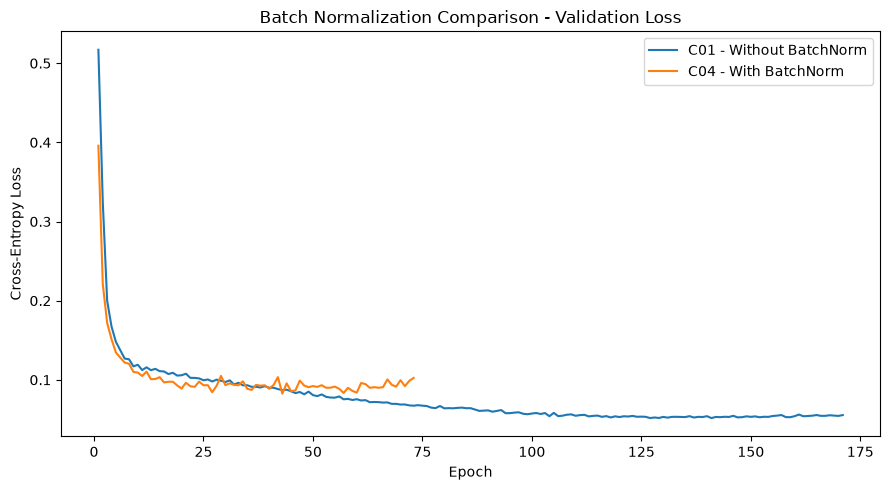

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["val_loss"],
    label="C01 - Without BatchNorm",
)

ax.plot(
    c04_history["epoch"],
    c04_history["val_loss"],
    label="C04 - With BatchNorm",
)

ax.set_title(
    "Batch Normalization Comparison - Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()

plt.tight_layout()
plt.show()

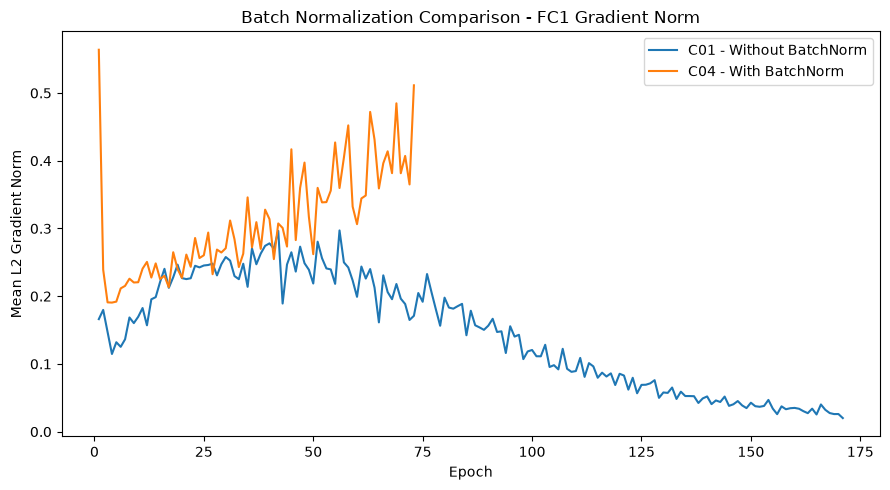

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["grad_fc1"],
    label="C01 - Without BatchNorm",
)

ax.plot(
    c04_history["epoch"],
    c04_history["grad_fc1"],
    label="C04 - With BatchNorm",
)

ax.set_title(
    "Batch Normalization Comparison - FC1 Gradient Norm"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")
ax.legend()

plt.tight_layout()
plt.show()

In [51]:
batchnorm_comparison = pd.DataFrame([
    summarize_at_best_epoch(
        "C01 - Without BatchNorm",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C04 - With BatchNorm",
        c04_history,
        c04_validation_metrics,
    ),
])

display(
    batchnorm_comparison.round(6)
)

,experiment,best_epoch,train_loss_at_best,val_loss_at_best,loss_gap_at_best,train_accuracy_at_best,val_accuracy_at_best,accuracy_gap_at_best,val_f1,global_grad_at_best,fc1_grad_at_best,fc2_grad_at_best,output_grad_at_best,learning_rate_at_best
0,C01 - Without BatchNorm,141,0.001531,0.051682,0.050151,1.000000,0.982609,0.017391,0.986111,0.045048,0.040668,0.011485,0.005377,0.001
1,C04 - With BatchNorm,43,0.050217,0.082542,0.032325,0.970205,0.956522,0.013683,0.964029,0.442489,0.300835,0.314370,0.047042,0.001


### C05 — Dropout e generalização

O experimento C05 investiga o efeito do Dropout sobre a diferença de desempenho entre treino e validação. A configuração de C01 será novamente utilizada como referência, acrescentando apenas Dropout com probabilidade de 0,2 após cada função de ativação das camadas ocultas. Durante o treinamento, o Dropout desativa aleatoriamente uma fração das ativações e reduz a dependência do modelo em combinações específicas de neurônios. A hipótese é que esse mecanismo pode reduzir overfitting, ainda que torne o treinamento mais difícil e possa aumentar a loss observada no conjunto de treino.

In [52]:
reset_random_seeds()

c05_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.2,
    initialization="default",
)

(
    c05_model,
    c05_history,
    c05_checkpoint,
    c05_validation_metrics,
) = train_classifier(
    model=c05_model,
    experiment_name="c05_relu_dropout",
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=False,
    early_stopping_patience=30,
)

display(c05_history.tail())

print(f"\nCheckpoint: {c05_checkpoint}")

print("\nValidation metrics:")

for metric_name, metric_value in c05_validation_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Epoch 001 | Train Loss: 0.6312 | Val Loss: 0.5261 | Val F1: 0.9645 | Grad Norm: 0.4561 | LR: 0.001000
Epoch 025 | Train Loss: 0.0741 | Val Loss: 0.1011 | Val F1: 0.9583 | Grad Norm: 0.3215 | LR: 0.001000
Epoch 050 | Train Loss: 0.0515 | Val Loss: 0.0883 | Val F1: 0.9650 | Grad Norm: 0.3070 | LR: 0.001000
Epoch 075 | Train Loss: 0.0285 | Val Loss: 0.0847 | Val F1: 0.9650 | Grad Norm: 0.2626 | LR: 0.001000
Epoch 100 | Train Loss: 0.0258 | Val Loss: 0.0787 | Val F1: 0.9650 | Grad Norm: 0.2861 | LR: 0.001000
Epoch 125 | Train Loss: 0.0152 | Val Loss: 0.0721 | Val F1: 0.9722 | Grad Norm: 0.2266 | LR: 0.001000
Early stopping at epoch 136.

Best epoch: 106
Best validation loss: 0.0615
Best validation F1: 0.9722


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,loss_gap,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
131,132,0.014162,0.082836,0.994413,0.965217,0.972222,0.972222,0.972222,0.068674,0.001,0.207242,0.585477,0.185480,0.055524,0.020486
132,133,0.015631,0.079647,0.994413,0.965217,0.972222,0.972222,0.972222,0.064016,0.001,0.213201,0.434397,0.190205,0.058677,0.025713
133,134,0.019336,0.076095,0.992551,0.965217,0.972222,0.972222,0.972222,0.056759,0.001,0.285637,0.834329,0.254931,0.074752,0.030428
134,135,0.018328,0.073566,0.994413,0.965217,0.972222,0.972222,0.972222,0.055238,0.001,0.242519,0.874892,0.214733,0.071467,0.026992
135,136,0.016857,0.078641,0.992551,0.965217,0.972222,0.972222,0.972222,0.061784,0.001,0.234959,1.077585,0.211649,0.064309,0.023731



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c05_relu_dropout_best.pt

Validation metrics:
loss: 0.0615
accuracy: 0.9652
precision: 0.9722
recall: 0.9722
f1: 0.9722


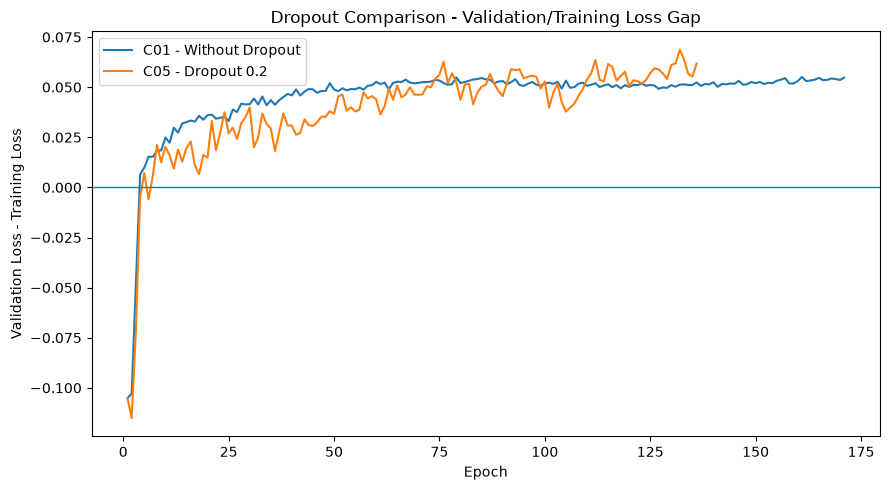

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["loss_gap"],
    label="C01 - Without Dropout",
)

ax.plot(
    c05_history["epoch"],
    c05_history["loss_gap"],
    label="C05 - Dropout 0.2",
)

ax.axhline(
    y=0.0,
    linewidth=1,
)

ax.set_title(
    "Dropout Comparison - Validation/Training Loss Gap"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss - Training Loss")
ax.legend()

plt.tight_layout()
plt.show()

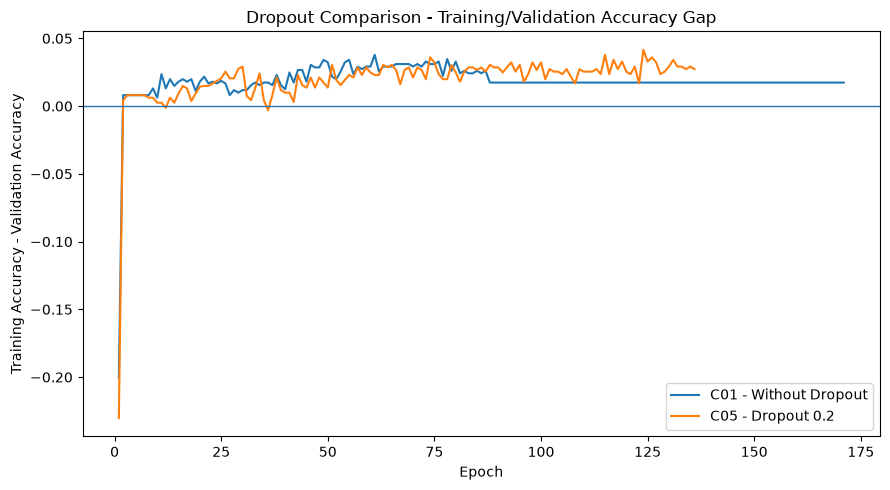

In [54]:
c01_accuracy_gap = (
    c01_history["train_accuracy"]
    - c01_history["val_accuracy"]
)

c05_accuracy_gap = (
    c05_history["train_accuracy"]
    - c05_history["val_accuracy"]
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_accuracy_gap,
    label="C01 - Without Dropout",
)

ax.plot(
    c05_history["epoch"],
    c05_accuracy_gap,
    label="C05 - Dropout 0.2",
)

ax.axhline(
    y=0.0,
    linewidth=1,
)

ax.set_title(
    "Dropout Comparison - Training/Validation Accuracy Gap"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Accuracy - Validation Accuracy")
ax.legend()

plt.tight_layout()
plt.show()

In [55]:
dropout_comparison = pd.DataFrame([
    summarize_at_best_epoch(
        "C01 - Without Dropout",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C05 - Dropout 0.2",
        c05_history,
        c05_validation_metrics,
    ),
])

display(
    dropout_comparison.round(6)
)

,experiment,best_epoch,train_loss_at_best,val_loss_at_best,loss_gap_at_best,train_accuracy_at_best,val_accuracy_at_best,accuracy_gap_at_best,val_f1,global_grad_at_best,fc1_grad_at_best,fc2_grad_at_best,output_grad_at_best,learning_rate_at_best
0,C01 - Without Dropout,141,0.001531,0.051682,0.050151,1.000000,0.982609,0.017391,0.986111,0.045048,0.040668,0.011485,0.005377,0.001
1,C05 - Dropout 0.2,106,0.021676,0.061519,0.039843,0.992551,0.965217,0.027334,0.972222,0.267424,0.240431,0.074556,0.028608,0.001


### C06 — Learning Rate Scheduling

O experimento C06 avalia o efeito de adaptar o learning rate ao longo do treinamento, a arquitetura e os demais hiperparâmetros permanecem iguais aos de C01, mas será utilizado `ReduceLROnPlateau`, monitorando a loss de validação. O treinamento começa com learning rate de 0,001, e quando a loss de validação permanece sem melhora durante oito épocas, o scheduler reduz o valor atual pela metade, respeitando um limite mínimo de `1e-6`. Espera-se que passos menores após a fase inicial de aprendizagem podem permitir refinamento dos pesos quando o modelo se aproxima de uma região de convergência.

In [56]:
reset_random_seeds()

c06_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

(
    c06_model,
    c06_history,
    c06_checkpoint,
    c06_validation_metrics,
) = train_classifier(
    model=c06_model,
    experiment_name="c06_relu_scheduler",
    epochs=200,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=True,
    early_stopping_patience=30,
)

display(c06_history.tail())

print(f"\nCheckpoint: {c06_checkpoint}")

print("\nValidation metrics:")

for metric_name, metric_value in c06_validation_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Epoch 001 | Train Loss: 0.6222 | Val Loss: 0.5170 | Val F1: 0.9645 | Grad Norm: 0.4600 | LR: 0.001000
Epoch 025 | Train Loss: 0.0664 | Val Loss: 0.0995 | Val F1: 0.9583 | Grad Norm: 0.3283 | LR: 0.001000
Epoch 050 | Train Loss: 0.0318 | Val Loss: 0.0807 | Val F1: 0.9650 | Grad Norm: 0.2509 | LR: 0.001000
Epoch 075 | Train Loss: 0.0140 | Val Loss: 0.0674 | Val F1: 0.9722 | Grad Norm: 0.2147 | LR: 0.001000
Epoch 100 | Train Loss: 0.0056 | Val Loss: 0.0574 | Val F1: 0.9861 | Grad Norm: 0.1319 | LR: 0.001000
Epoch 125 | Train Loss: 0.0024 | Val Loss: 0.0535 | Val F1: 0.9861 | Grad Norm: 0.0756 | LR: 0.001000
Epoch 150 | Train Loss: 0.0014 | Val Loss: 0.0531 | Val F1: 0.9861 | Grad Norm: 0.0484 | LR: 0.000250
Early stopping at epoch 157.

Best epoch: 127
Best validation loss: 0.0517
Best validation F1: 0.9861


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,val_precision,val_recall,val_f1,loss_gap,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
152,153,0.001387,0.053344,1.0,0.982609,0.986111,0.986111,0.986111,0.051957,0.000250,0.048349,0.129263,0.043981,0.010790,0.005433
153,154,0.001420,0.053460,1.0,0.982609,0.986111,0.986111,0.986111,0.052040,0.000125,0.053441,0.213834,0.048904,0.011556,0.005225
154,155,0.001363,0.053690,1.0,0.982609,0.986111,0.986111,0.986111,0.052327,0.000125,0.046140,0.154621,0.041182,0.011348,0.005901
155,156,0.001355,0.053687,1.0,0.982609,0.986111,0.986111,0.986111,0.052333,0.000125,0.036613,0.114873,0.033172,0.008384,0.004402
156,157,0.001359,0.053817,1.0,0.982609,0.986111,0.986111,0.986111,0.052458,0.000125,0.043276,0.128997,0.039281,0.010507,0.004935



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c06_relu_scheduler_best.pt

Validation metrics:
loss: 0.0517
accuracy: 0.9826
precision: 0.9861
recall: 0.9861
f1: 0.9861


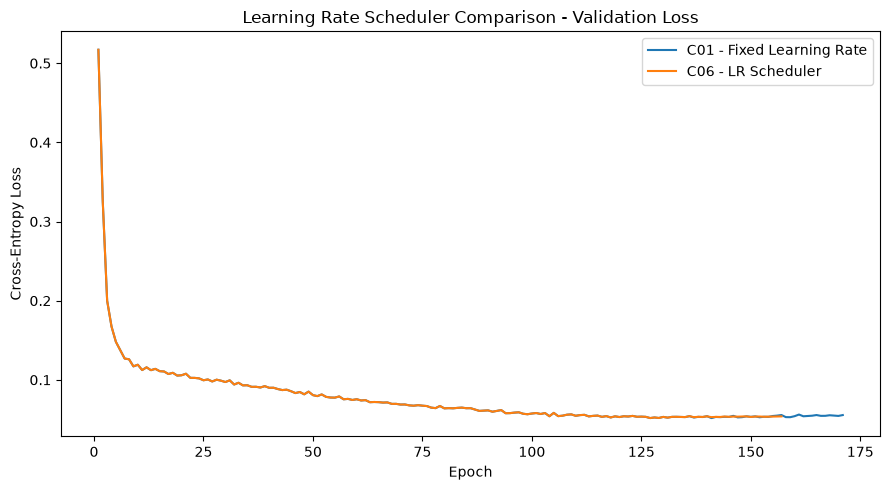

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c01_history["epoch"],
    c01_history["val_loss"],
    label="C01 - Fixed Learning Rate",
)

ax.plot(
    c06_history["epoch"],
    c06_history["val_loss"],
    label="C06 - LR Scheduler",
)

ax.set_title(
    "Learning Rate Scheduler Comparison - Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()

plt.tight_layout()
plt.show()

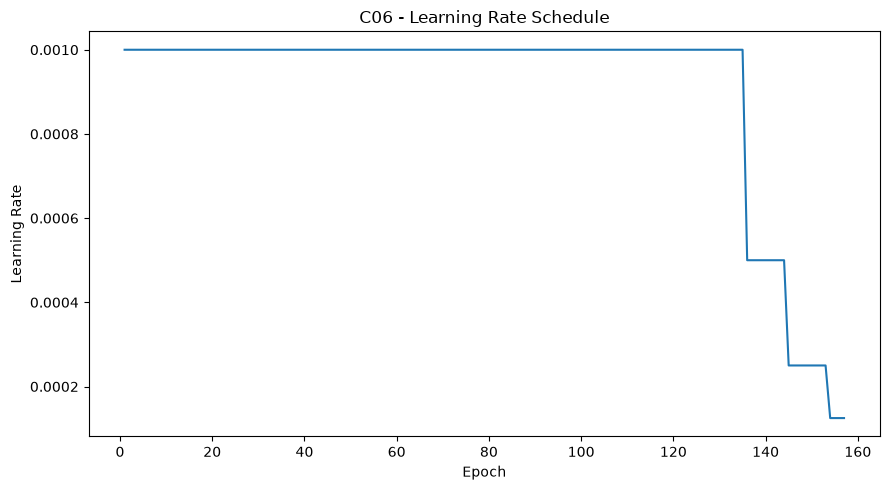

In [58]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    c06_history["epoch"],
    c06_history["learning_rate"],
)

ax.set_title(
    "C06 - Learning Rate Schedule"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

In [59]:
scheduler_comparison = pd.DataFrame([
    summarize_at_best_epoch(
        "C01 - Fixed Learning Rate",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C06 - LR Scheduler",
        c06_history,
        c06_validation_metrics,
    ),
])

display(
    scheduler_comparison.round(6)
)

,experiment,best_epoch,train_loss_at_best,val_loss_at_best,loss_gap_at_best,train_accuracy_at_best,val_accuracy_at_best,accuracy_gap_at_best,val_f1,global_grad_at_best,fc1_grad_at_best,fc2_grad_at_best,output_grad_at_best,learning_rate_at_best
0,C01 - Fixed Learning Rate,141,0.001531,0.051682,0.050151,1.0,0.982609,0.017391,0.986111,0.045048,0.040668,0.011485,0.005377,0.001
1,C06 - LR Scheduler,127,0.002495,0.051710,0.049216,1.0,0.982609,0.017391,0.986111,0.078794,0.071347,0.020182,0.009581,0.001


### Análise das técnicas de estabilização e regularização

A inclusão de Batch Normalization em C04 modificou de forma clara a dinâmica do treinamento, o melhor resultado foi atingido na época 43, consideravelmente antes da época 141 observada em C01, e o gap entre as losses de treino e validação caiu de aproximadamente 0,0502 para 0,0323. Apesar dessa redução, a configuração apresentou `val_loss` de aproximadamente 0,0825 e F1 de 0,9640, inferiores aos resultados de C01. Os gradient norms também permaneceram mais elevados, especialmente nas primeiras camadas, dessa forma, o BatchNorm alterou a escala dos gradientes e reduziu a diferença entre treino e validação, mas não melhorou o desempenho final neste problema.

O Dropout de 0,2 utilizado em C05 também reduziu o gap de loss, que passou de aproximadamente 0,0502 para 0,0398 no melhor ponto de cada experimento. Entretanto, a accuracy de validação caiu para aproximadamente 0,9652 e o F1 para 0,9722. O gap de accuracy não apresentou a mesma redução observada na loss, indicando que o efeito regularizador não se traduziu diretamente em maior capacidade de generalização. Neste conjunto de dados relativamente pequeno e com uma arquitetura já moderada, a regularização adicional reduziu parcialmente o ajuste excessivo da loss, mas também limitou o desempenho do classificador.

O scheduler utilizado em C06 manteve praticamente o mesmo resultado de C01, com F1 de aproximadamente 0,9861 e `val_loss` de 0,0517, o learning rate foi reduzido após períodos sem melhora da validação, porém o melhor checkpoint ocorreu antes dessas reduções. Assim, o decaimento foi executado e monitorado corretamente, mas não proporcionou refinamento adicional do modelo neste experimento.

In [60]:
classification_experiment_summary = pd.DataFrame([
    summarize_at_best_epoch(
        "C01 - ReLU / Default",
        c01_history,
        c01_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C02 - Tanh / Default",
        c02_history,
        c02_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C03 - ReLU / He",
        c03_history,
        c03_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C04 - ReLU / BatchNorm",
        c04_history,
        c04_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C05 - ReLU / Dropout 0.2",
        c05_history,
        c05_validation_metrics,
    ),
    summarize_at_best_epoch(
        "C06 - ReLU / Scheduler",
        c06_history,
        c06_validation_metrics,
    ),
])

classification_experiment_summary = (
    classification_experiment_summary
    .sort_values(
        by=["val_f1", "val_loss_at_best"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(
    classification_experiment_summary.round(6)
)

,experiment,best_epoch,train_loss_at_best,val_loss_at_best,loss_gap_at_best,train_accuracy_at_best,val_accuracy_at_best,accuracy_gap_at_best,val_f1,global_grad_at_best,fc1_grad_at_best,fc2_grad_at_best,output_grad_at_best,learning_rate_at_best
0,C01 - ReLU / Default,141,0.001531,0.051682,0.050151,1.000000,0.982609,0.017391,0.986111,0.045048,0.040668,0.011485,0.005377,0.001
1,C06 - ReLU / Scheduler,127,0.002495,0.051710,0.049216,1.000000,0.982609,0.017391,0.986111,0.078794,0.071347,0.020182,0.009581,0.001
2,C02 - Tanh / Default,199,0.005105,0.033506,0.028401,1.000000,0.982609,0.017391,0.985915,0.104462,0.091617,0.037541,0.017710,0.001
3,C05 - ReLU / Dropout 0.2,106,0.021676,0.061519,0.039843,0.992551,0.965217,0.027334,0.972222,0.267424,0.240431,0.074556,0.028608,0.001
4,C03 - ReLU / He,22,0.061431,0.102585,0.041154,0.972067,0.956522,0.015545,0.965035,0.302262,0.154700,0.166958,0.186253,0.001
5,C04 - ReLU / BatchNorm,43,0.050217,0.082542,0.032325,0.970205,0.956522,0.013683,0.964029,0.442489,0.300835,0.314370,0.047042,0.001


In [61]:
classification_summary_path = (
    ARTIFACTS_DIR
    / "classification_experiment_summary.csv"
)

classification_experiment_summary.to_csv(
    classification_summary_path,
    index=False,
)

print(
    f"Classification experiment summary saved to: "
    f"{classification_summary_path}"
)

Classification experiment summary saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\classification_experiment_summary.csv


## Diagnóstico controlado do fluxo de gradientes

Os experimentos anteriores mostraram diferenças relevantes na magnitude dos gradientes, mas nenhum deles apresentou evidência suficiente para classificar o comportamento como vanishing ou exploding gradients. Para investigar esse fenômeno de forma objetiva, será realizado um experimento diagnóstico separado, sem utilizá-lo para selecionar o modelo final. A hipótese formulada antes da execução é que aumentar significativamente a profundidade da MLP e utilizar Tanh em todas as camadas ocultas pode provocar atenuação progressiva dos gradientes durante a retropropagação. Se essa hipótese estiver correta, espera-se observar gradient norms substancialmente menores nas primeiras camadas em comparação às camadas próximas da saída.

In [62]:
class DeepDiagnosticMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        activation_name="tanh",
        initialization="default",
    ):
        super().__init__()

        self.activation_name = activation_name
        self.initialization = initialization

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, 64)
        self.fc6 = nn.Linear(64, 64)
        self.fc7 = nn.Linear(64, 64)
        self.fc8 = nn.Linear(64, 64)

        self.output = nn.Linear(
            64,
            output_dim,
        )

        self.activation1 = self._create_activation()
        self.activation2 = self._create_activation()
        self.activation3 = self._create_activation()
        self.activation4 = self._create_activation()
        self.activation5 = self._create_activation()
        self.activation6 = self._create_activation()
        self.activation7 = self._create_activation()
        self.activation8 = self._create_activation()

        if initialization == "he":
            self._apply_he_initialization()
        elif initialization != "default":
            raise ValueError(
                "Initialization must be 'default' or 'he'."
            )

    def _create_activation(self):
        if self.activation_name == "relu":
            return nn.ReLU()

        if self.activation_name == "tanh":
            return nn.Tanh()

        raise ValueError(
            "Activation must be 'relu' or 'tanh'."
        )

    def _apply_he_initialization(self):
        hidden_layers = [
            self.fc1,
            self.fc2,
            self.fc3,
            self.fc4,
            self.fc5,
            self.fc6,
            self.fc7,
            self.fc8,
        ]

        for layer in hidden_layers:
            nn.init.kaiming_normal_(
                layer.weight,
                mode="fan_in",
                nonlinearity="relu",
            )

            nn.init.zeros_(
                layer.bias
            )

    def forward(self, x):
        x = self.activation1(
            self.fc1(x)
        )

        x = self.activation2(
            self.fc2(x)
        )

        x = self.activation3(
            self.fc3(x)
        )

        x = self.activation4(
            self.fc4(x)
        )

        x = self.activation5(
            self.fc5(x)
        )

        x = self.activation6(
            self.fc6(x)
        )

        x = self.activation7(
            self.fc7(x)
        )

        x = self.activation8(
            self.fc8(x)
        )

        return self.output(x)


diagnostic_model_example = DeepDiagnosticMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="tanh",
    initialization="default",
)

print(diagnostic_model_example)

print(
    f"\nTrainable parameters: "
    f"{count_trainable_parameters(diagnostic_model_example):,}"
)

DeepDiagnosticMLP(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=64, bias=True)
  (fc5): Linear(in_features=64, out_features=64, bias=True)
  (fc6): Linear(in_features=64, out_features=64, bias=True)
  (fc7): Linear(in_features=64, out_features=64, bias=True)
  (fc8): Linear(in_features=64, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=2, bias=True)
  (activation1): Tanh()
  (activation2): Tanh()
  (activation3): Tanh()
  (activation4): Tanh()
  (activation5): Tanh()
  (activation6): Tanh()
  (activation7): Tanh()
  (activation8): Tanh()
)

Trainable parameters: 30,338


In [63]:
def compute_diagnostic_gradient_norms(model):
    tracked_parameters = [
        "fc1.weight",
        "fc2.weight",
        "fc4.weight",
        "fc6.weight",
        "fc8.weight",
        "output.weight",
    ]

    gradient_norms = {}

    for name, parameter in model.named_parameters():
        if (
            name in tracked_parameters
            and parameter.grad is not None
        ):
            gradient_norms[name] = (
                parameter.grad
                .detach()
                .norm(p=2)
                .item()
            )

    return gradient_norms

In [64]:
def train_gradient_diagnostic(
    model,
    experiment_name,
    epochs=80,
    learning_rate=1e-3,
):
    reset_random_seeds()

    train_loader, val_loader, _ = create_dataloaders(
        "classification"
    )

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )

    run_dir = (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "gradient_diagnostics"
        / experiment_name
    )

    if run_dir.exists():
        shutil.rmtree(run_dir)

    writer = SummaryWriter(
        log_dir=run_dir
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}_best.pt"
    )

    best_val_loss = float("inf")
    history = []

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        running_loss = 0.0
        total_samples = 0

        epoch_gradient_norms = {
            "fc1": [],
            "fc2": [],
            "fc4": [],
            "fc6": [],
            "fc8": [],
            "output": [],
        }

        for features, targets in train_loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(features)

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()

            gradient_norms = (
                compute_diagnostic_gradient_norms(
                    model
                )
            )

            epoch_gradient_norms["fc1"].append(
                gradient_norms["fc1.weight"]
            )

            epoch_gradient_norms["fc2"].append(
                gradient_norms["fc2.weight"]
            )

            epoch_gradient_norms["fc4"].append(
                gradient_norms["fc4.weight"]
            )

            epoch_gradient_norms["fc6"].append(
                gradient_norms["fc6.weight"]
            )

            epoch_gradient_norms["fc8"].append(
                gradient_norms["fc8.weight"]
            )

            epoch_gradient_norms["output"].append(
                gradient_norms["output.weight"]
            )

            optimizer.step()

            batch_size = features.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

        train_loss = (
            running_loss
            / total_samples
        )

        validation_metrics = evaluate_classifier(
            model,
            val_loader,
            criterion,
        )

        mean_gradients = {
            layer: float(
                np.mean(values)
            )
            for layer, values
            in epoch_gradient_norms.items()
        }

        first_to_output_ratio = (
            mean_gradients["fc1"]
            / max(
                mean_gradients["output"],
                1e-12,
            )
        )

        writer.add_scalars(
            "Loss",
            {
                "train": train_loss,
                "validation": validation_metrics[
                    "loss"
                ],
            },
            epoch,
        )

        for layer, value in mean_gradients.items():
            writer.add_scalar(
                f"GradientNorm/{layer}",
                value,
                epoch,
            )

        writer.add_scalar(
            "GradientNorm/first_to_output_ratio",
            first_to_output_ratio,
            epoch,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": validation_metrics[
                "loss"
            ],
            "val_f1": validation_metrics[
                "f1"
            ],
            "grad_fc1": mean_gradients["fc1"],
            "grad_fc2": mean_gradients["fc2"],
            "grad_fc4": mean_gradients["fc4"],
            "grad_fc6": mean_gradients["fc6"],
            "grad_fc8": mean_gradients["fc8"],
            "grad_output": mean_gradients[
                "output"
            ],
            "first_to_output_ratio": (
                first_to_output_ratio
            ),
        })

        if (
            validation_metrics["loss"]
            < best_val_loss
        ):
            best_val_loss = (
                validation_metrics["loss"]
            )

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )

        if (
            epoch == 1
            or epoch % 20 == 0
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: "
                f"{validation_metrics['loss']:.4f} | "
                f"FC1 Grad: "
                f"{mean_gradients['fc1']:.6f} | "
                f"Output Grad: "
                f"{mean_gradients['output']:.6f} | "
                f"Ratio: "
                f"{first_to_output_ratio:.6f}"
            )

    writer.close()

    return (
        model,
        pd.DataFrame(history),
        checkpoint_path,
    )

In [65]:
reset_random_seeds()

d01_model = DeepDiagnosticMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="tanh",
    initialization="default",
)

(
    d01_model,
    d01_history,
    d01_checkpoint,
) = train_gradient_diagnostic(
    model=d01_model,
    experiment_name="d01_deep_tanh_default",
    epochs=80,
    learning_rate=1e-3,
)

display(
    d01_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{d01_checkpoint}"
)

Epoch 001 | Train Loss: 0.4453 | Val Loss: 0.2000 | FC1 Grad: 0.088929 | Output Grad: 0.171469 | Ratio: 0.518631
Epoch 020 | Train Loss: 0.0905 | Val Loss: 0.1438 | FC1 Grad: 0.506805 | Output Grad: 0.054073 | Ratio: 9.372670
Epoch 040 | Train Loss: 0.0803 | Val Loss: 0.1109 | FC1 Grad: 0.574739 | Output Grad: 0.039670 | Ratio: 14.487968
Epoch 060 | Train Loss: 0.0753 | Val Loss: 0.1167 | FC1 Grad: 0.528664 | Output Grad: 0.035931 | Ratio: 14.713245
Epoch 080 | Train Loss: 0.0714 | Val Loss: 0.1221 | FC1 Grad: 0.676243 | Output Grad: 0.041962 | Ratio: 16.115511


,epoch,train_loss,val_loss,val_f1,grad_fc1,grad_fc2,grad_fc4,grad_fc6,grad_fc8,grad_output,first_to_output_ratio
75,76,0.074867,0.128122,0.971429,0.664599,0.452792,0.063086,0.044357,0.026065,0.037698,17.629455
76,77,0.081072,0.107608,0.958333,0.482610,0.334812,0.057409,0.049653,0.032505,0.049767,9.697434
77,78,0.070145,0.118537,0.957746,0.525846,0.346446,0.054401,0.037519,0.024253,0.037424,14.050875
78,79,0.070617,0.127704,0.957746,0.591251,0.371345,0.055668,0.039052,0.024579,0.037224,15.883595
79,80,0.071364,0.122132,0.958333,0.676243,0.448148,0.060927,0.041522,0.025831,0.041962,16.115511



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\d01_deep_tanh_default_best.pt


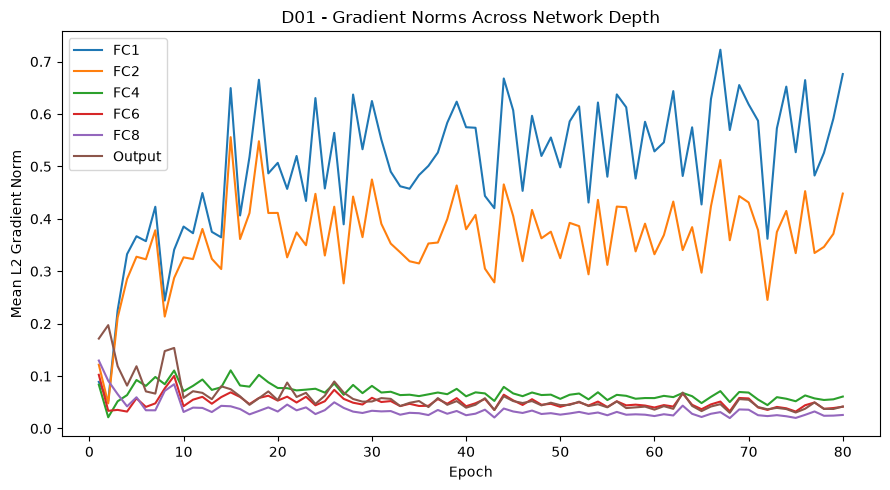

In [66]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    d01_history["epoch"],
    d01_history["grad_fc1"],
    label="FC1",
)

ax.plot(
    d01_history["epoch"],
    d01_history["grad_fc2"],
    label="FC2",
)

ax.plot(
    d01_history["epoch"],
    d01_history["grad_fc4"],
    label="FC4",
)

ax.plot(
    d01_history["epoch"],
    d01_history["grad_fc6"],
    label="FC6",
)

ax.plot(
    d01_history["epoch"],
    d01_history["grad_fc8"],
    label="FC8",
)

ax.plot(
    d01_history["epoch"],
    d01_history["grad_output"],
    label="Output",
)

ax.set_title(
    "D01 - Gradient Norms Across Network Depth"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")
ax.legend()

plt.tight_layout()
plt.show()

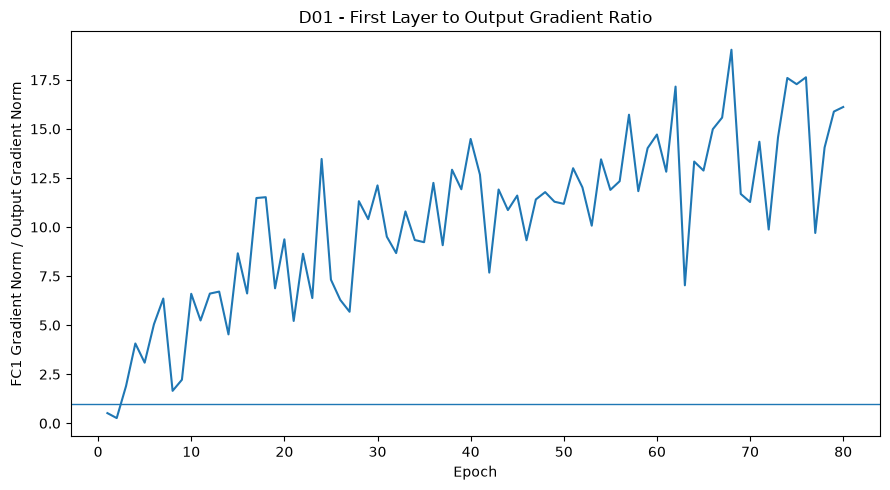

In [67]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    d01_history["epoch"],
    d01_history[
        "first_to_output_ratio"
    ],
)

ax.axhline(
    y=1.0,
    linewidth=1,
)

ax.set_title(
    "D01 - First Layer to Output Gradient Ratio"
)

ax.set_xlabel("Epoch")

ax.set_ylabel(
    "FC1 Gradient Norm / Output Gradient Norm"
)

plt.tight_layout()
plt.show()

In [68]:
d01_gradient_summary = pd.DataFrame({
    "metric": [
        "mean_fc1_gradient",
        "mean_fc4_gradient",
        "mean_fc8_gradient",
        "mean_output_gradient",
        "mean_first_to_output_ratio",
        "minimum_first_to_output_ratio",
        "best_validation_loss",
        "best_validation_f1",
    ],
    "value": [
        d01_history["grad_fc1"].mean(),
        d01_history["grad_fc4"].mean(),
        d01_history["grad_fc8"].mean(),
        d01_history["grad_output"].mean(),
        d01_history[
            "first_to_output_ratio"
        ].mean(),
        d01_history[
            "first_to_output_ratio"
        ].min(),
        d01_history["val_loss"].min(),
        d01_history.loc[
            d01_history["val_loss"].idxmin(),
            "val_f1",
        ],
    ],
})

display(
    d01_gradient_summary.round(8)
)

,metric,value
0,mean_fc1_gradient,0.506643
1,mean_fc4_gradient,0.068513
2,mean_fc8_gradient,0.035108
3,mean_output_gradient,0.059123
4,mean_first_to_output_ratio,10.323961
5,minimum_first_to_output_ratio,0.265766
6,best_validation_loss,0.097877
7,best_validation_f1,0.965035


### Resultado do diagnóstico D01

A hipótese de vanishing gradients na MLP profunda com Tanh não foi confirmada. Embora a arquitetura possua oito camadas ocultas, a norma média do gradiente da primeira camada foi aproximadamente 0,5066, enquanto a camada de saída apresentou aproximadamente 0,0591. A razão média entre essas duas normas foi 10,32 e chegou a valores superiores a 16 ao final do treinamento. Esse comportamento é oposto ao esperado para vanishing gradients, pois o sinal recebido pela primeira camada não se tornou sistematicamente menor que o observado próximo à saída. As magnitudes absolutas também não apresentaram valores suficientes para caracterizar exploding gradients. Portanto, os resultados indicam um fluxo de gradientes desequilibrado entre as camadas, mas não permitem classificar o fenômeno como vanishing ou exploding gradients.

A hipótese inicial é, portanto, rejeitada. Além disso, a arquitetura profunda não apresentou vantagem de desempenho: sua melhor loss de validação foi aproximadamente 0,0979, com F1 de 0,9650, valores inferiores aos obtidos pela MLP rasa utilizada nos experimentos principais, isso reforça a decisão de manter uma arquitetura proporcional ao tamanho e à complexidade deste conjunto de dados.

### D02 — Diagnóstico do efeito da escala das entradas sobre os gradientes

A análise exploratória mostrou diferenças expressivas de escala entre as variáveis do dataset. Algumas características possuem valores inferiores a 1, enquanto outras atingem várias centenas, o pipeline principal corrige essa diferença com `StandardScaler`, mas será realizada uma ablação controlada removendo exclusivamente essa padronização para investigar sua influência sobre o fluxo de gradientes.

A hipótese formulada antes da execução é que utilizar diretamente as magnitudes originais das variáveis numéricas produzirá gradient norms substancialmente maiores, especialmente na primeira camada, pois o gradiente associado aos pesos dessa camada depende diretamente da magnitude de suas entradas e também se espera maior instabilidade da loss durante o treinamento. As variáveis categóricas continuarão utilizando One-Hot Encoding para que a comparação modifique somente a escala das variáveis quantitativas. Caso a hipótese seja confirmada, a correção será aplicar novamente a padronização e repetir o mesmo experimento mantendo todos os demais componentes constantes.

In [69]:
unscaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_unscaled = unscaled_preprocessor.fit_transform(
    X_train
)

X_val_unscaled = unscaled_preprocessor.transform(
    X_val
)

X_train_unscaled = np.asarray(
    X_train_unscaled,
    dtype=np.float32,
)

X_val_unscaled = np.asarray(
    X_val_unscaled,
    dtype=np.float32,
)

print(
    f"Scaled training shape:   "
    f"{X_train_processed.shape}"
)

print(
    f"Unscaled training shape: "
    f"{X_train_unscaled.shape}"
)

print("\nFirst scaled sample:")
print(
    np.round(
        X_train_processed[0],
        4,
    )
)

print("\nFirst unscaled sample:")
print(
    np.round(
        X_train_unscaled[0],
        4,
    )
)

Scaled training shape:   (537, 16)
Unscaled training shape: (537, 16)

First scaled sample:
[-1.3406  1.5242  1.1213  0.9461 -0.9724  0.1049  0.      0.      1.
  0.      0.      1.      0.      0.      0.      0.    ]

First unscaled sample:
[6.200e-01 8.085e+02 3.675e+02 2.205e+02 3.500e+00 2.500e-01 0.000e+00
 0.000e+00 1.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00]


In [70]:
X_train_unscaled_tensor = torch.tensor(
    X_train_unscaled,
    dtype=torch.float32,
)

X_val_unscaled_tensor = torch.tensor(
    X_val_unscaled,
    dtype=torch.float32,
)

unscaled_classification_datasets = {
    "train": TensorDataset(
        X_train_unscaled_tensor,
        y_train_class_tensor,
    ),
    "validation": TensorDataset(
        X_val_unscaled_tensor,
        y_val_class_tensor,
    ),
}


def create_scaling_diagnostic_loaders(
    use_scaled,
    seed=SEED,
):
    if use_scaled:
        train_dataset = classification_datasets[
            "train"
        ]

        val_dataset = classification_datasets[
            "validation"
        ]

    else:
        train_dataset = (
            unscaled_classification_datasets[
                "train"
            ]
        )

        val_dataset = (
            unscaled_classification_datasets[
                "validation"
            ]
        )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return train_loader, val_loader

In [71]:
def train_scaling_diagnostic(
    model,
    train_loader,
    val_loader,
    experiment_name,
    epochs=60,
    learning_rate=1e-3,
):
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )

    run_dir = (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "gradient_diagnostics"
        / experiment_name
    )

    if run_dir.exists():
        shutil.rmtree(run_dir)

    writer = SummaryWriter(
        log_dir=run_dir
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}_best.pt"
    )

    best_val_loss = float("inf")
    history = []

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        running_loss = 0.0
        total_samples = 0

        global_gradient_norms = []
        fc1_gradient_norms = []

        for features, targets in train_loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(features)

            loss = criterion(
                logits,
                targets,
            )

            loss.backward()

            global_norm, layer_norms = (
                compute_gradient_norms(model)
            )

            global_gradient_norms.append(
                global_norm
            )

            fc1_gradient_norms.append(
                layer_norms["fc1.weight"]
            )

            optimizer.step()

            batch_size = features.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

        train_loss = (
            running_loss
            / total_samples
        )

        validation_metrics = evaluate_classifier(
            model,
            val_loader,
            criterion,
        )

        global_grad_mean = float(
            np.mean(
                global_gradient_norms
            )
        )

        global_grad_max = float(
            np.max(
                global_gradient_norms
            )
        )

        fc1_grad_mean = float(
            np.mean(
                fc1_gradient_norms
            )
        )

        fc1_grad_max = float(
            np.max(
                fc1_gradient_norms
            )
        )

        writer.add_scalars(
            "Loss",
            {
                "train": train_loss,
                "validation": validation_metrics[
                    "loss"
                ],
            },
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_mean",
            global_grad_mean,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_max",
            global_grad_max,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/fc1_mean",
            fc1_grad_mean,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/fc1_max",
            fc1_grad_max,
            epoch,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": validation_metrics[
                "loss"
            ],
            "val_f1": validation_metrics[
                "f1"
            ],
            "global_grad_mean": (
                global_grad_mean
            ),
            "global_grad_max": (
                global_grad_max
            ),
            "fc1_grad_mean": (
                fc1_grad_mean
            ),
            "fc1_grad_max": (
                fc1_grad_max
            ),
        })

        if (
            validation_metrics["loss"]
            < best_val_loss
        ):
            best_val_loss = (
                validation_metrics["loss"]
            )

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )

        if (
            epoch == 1
            or epoch % 10 == 0
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: "
                f"{validation_metrics['loss']:.4f} | "
                f"Global Grad Mean: "
                f"{global_grad_mean:.4f} | "
                f"Global Grad Max: "
                f"{global_grad_max:.4f} | "
                f"FC1 Grad Mean: "
                f"{fc1_grad_mean:.4f}"
            )

    writer.close()

    return (
        model,
        pd.DataFrame(history),
        checkpoint_path,
    )

In [72]:
reset_random_seeds()

(
    d02_train_loader,
    d02_val_loader,
) = create_scaling_diagnostic_loaders(
    use_scaled=False
)

d02_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

(
    d02_model,
    d02_history,
    d02_checkpoint,
) = train_scaling_diagnostic(
    model=d02_model,
    train_loader=d02_train_loader,
    val_loader=d02_val_loader,
    experiment_name="d02_unscaled_inputs",
    epochs=60,
    learning_rate=1e-3,
)

display(
    d02_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{d02_checkpoint}"
)

Epoch 001 | Train Loss: 0.8998 | Val Loss: 0.1741 | Global Grad Mean: 157.7204 | Global Grad Max: 318.4695 | FC1 Grad Mean: 66.7987
Epoch 010 | Train Loss: 0.2036 | Val Loss: 0.1651 | Global Grad Mean: 39.9648 | Global Grad Max: 84.1702 | FC1 Grad Mean: 18.1413
Epoch 020 | Train Loss: 0.1840 | Val Loss: 0.1856 | Global Grad Mean: 25.8038 | Global Grad Max: 73.3810 | FC1 Grad Mean: 12.4043
Epoch 030 | Train Loss: 0.2405 | Val Loss: 0.1930 | Global Grad Mean: 49.9971 | Global Grad Max: 121.1820 | FC1 Grad Mean: 23.0205
Epoch 040 | Train Loss: 0.3007 | Val Loss: 0.1706 | Global Grad Mean: 58.2231 | Global Grad Max: 124.9012 | FC1 Grad Mean: 27.4971
Epoch 050 | Train Loss: 0.2346 | Val Loss: 0.2878 | Global Grad Mean: 40.1414 | Global Grad Max: 154.9442 | FC1 Grad Mean: 19.4277
Epoch 060 | Train Loss: 0.2243 | Val Loss: 0.1920 | Global Grad Mean: 32.3832 | Global Grad Max: 87.0002 | FC1 Grad Mean: 15.9407


,epoch,train_loss,val_loss,val_f1,global_grad_mean,global_grad_max,fc1_grad_mean,fc1_grad_max
55,56,0.177220,0.166136,0.964539,26.238133,86.772495,12.804776,41.705818
56,57,0.156204,0.309955,0.964539,19.422827,43.619742,9.150007,20.602318
57,58,0.229859,0.192907,0.964539,44.096367,115.809029,21.492448,56.133835
58,59,0.202204,0.209291,0.925170,29.706173,87.066544,14.615392,42.783005
59,60,0.224319,0.192048,0.964539,32.383234,87.000228,15.940705,42.005295



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\d02_unscaled_inputs_best.pt


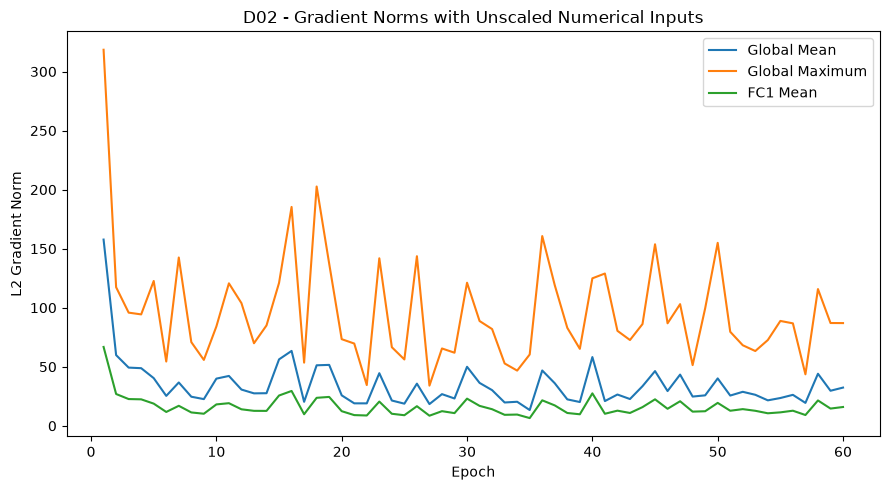

In [73]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    d02_history["epoch"],
    d02_history["global_grad_mean"],
    label="Global Mean",
)

ax.plot(
    d02_history["epoch"],
    d02_history["global_grad_max"],
    label="Global Maximum",
)

ax.plot(
    d02_history["epoch"],
    d02_history["fc1_grad_mean"],
    label="FC1 Mean",
)

ax.set_title(
    "D02 - Gradient Norms with Unscaled Numerical Inputs"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("L2 Gradient Norm")
ax.legend()

plt.tight_layout()
plt.show()

In [74]:
d02_summary = pd.DataFrame({
    "metric": [
        "initial_global_gradient_mean",
        "initial_global_gradient_max",
        "maximum_global_gradient",
        "mean_global_gradient",
        "initial_fc1_gradient_mean",
        "maximum_fc1_gradient",
        "mean_fc1_gradient",
        "best_validation_loss",
        "best_validation_f1",
    ],
    "value": [
        d02_history.iloc[0][
            "global_grad_mean"
        ],
        d02_history.iloc[0][
            "global_grad_max"
        ],
        d02_history[
            "global_grad_max"
        ].max(),
        d02_history[
            "global_grad_mean"
        ].mean(),
        d02_history.iloc[0][
            "fc1_grad_mean"
        ],
        d02_history[
            "fc1_grad_max"
        ].max(),
        d02_history[
            "fc1_grad_mean"
        ].mean(),
        d02_history[
            "val_loss"
        ].min(),
        d02_history.loc[
            d02_history[
                "val_loss"
            ].idxmin(),
            "val_f1",
        ],
    ],
})

display(
    d02_summary.round(6)
)

,metric,value
0,initial_global_gradient_mean,157.720374
1,initial_global_gradient_max,318.469465
2,maximum_global_gradient,318.469465
3,mean_global_gradient,34.571530
4,initial_fc1_gradient_mean,66.798657
5,maximum_fc1_gradient,134.351562
6,mean_fc1_gradient,16.159374
7,best_validation_loss,0.158745
8,best_validation_f1,0.964539


### Diagnóstico do D02

A hipótese formulada antes do experimento foi confirmada. Quando as variáveis numéricas foram utilizadas em suas escalas originais, a magnitude dos gradientes aumentou de forma extrema, o gradient norm global médio da primeira época foi aproximadamente 157,72 e o maior valor observado chegou a 318,47. Na primeira camada, o gradient norm médio inicial foi aproximadamente 66,80 e o maior valor observado durante o treinamento chegou a 134,35, essas magnitudes são várias ordens superiores às observadas na configuração padronizada utilizada nos experimentos principais. A loss também apresentou oscilações ao longo do treinamento, sem estabelecer a convergência estável observada anteriormente, comportamento que caracteriza instabilidade de gradientes compatível com exploding gradients, causada pela grande diferença de escala entre as características de entrada.

O experimento também apresentou pior capacidade de generalização, com melhor `val_loss` de aproximadamente 0,1587 e F1 de 0,9645 e a evidência sugere que a ausência de padronização prejudica tanto a estabilidade da otimização quanto o desempenho da rede.

### D03 — Correção pela padronização das entradas

A correção aplicada consiste em restaurar a padronização das variáveis numéricas com `StandardScaler`, mantendo exatamente a mesma arquitetura, inicialização, função de ativação, otimizador, learning rate, batch size e número de épocas utilizados em D02. É suposto que a padronização reduzirá substancialmente os gradient norms, especialmente na primeira camada, e produzirá uma curva de loss mais estável. Como apenas a escala das entradas será alterada entre D02 e D03, a comparação permite medir diretamente o efeito dessa correção.

In [75]:
reset_random_seeds()

(
    d03_train_loader,
    d03_val_loader,
) = create_scaling_diagnostic_loaders(
    use_scaled=True
)

d03_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

(
    d03_model,
    d03_history,
    d03_checkpoint,
) = train_scaling_diagnostic(
    model=d03_model,
    train_loader=d03_train_loader,
    val_loader=d03_val_loader,
    experiment_name="d03_scaled_inputs",
    epochs=60,
    learning_rate=1e-3,
)

display(
    d03_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{d03_checkpoint}"
)

Epoch 001 | Train Loss: 0.6222 | Val Loss: 0.5170 | Global Grad Mean: 0.4600 | Global Grad Max: 0.6643 | FC1 Grad Mean: 0.1662
Epoch 010 | Train Loss: 0.0942 | Val Loss: 0.1191 | Global Grad Mean: 0.2635 | Global Grad Max: 0.5922 | FC1 Grad Mean: 0.1696
Epoch 020 | Train Loss: 0.0698 | Val Loss: 0.1058 | Global Grad Mean: 0.3099 | Global Grad Max: 0.6917 | FC1 Grad Mean: 0.2267
Epoch 030 | Train Loss: 0.0557 | Val Loss: 0.0972 | Global Grad Mean: 0.3585 | Global Grad Max: 0.6215 | FC1 Grad Mean: 0.2579
Epoch 040 | Train Loss: 0.0440 | Val Loss: 0.0900 | Global Grad Mean: 0.3347 | Global Grad Max: 0.8540 | FC1 Grad Mean: 0.2780
Epoch 050 | Train Loss: 0.0318 | Val Loss: 0.0807 | Global Grad Mean: 0.2509 | Global Grad Max: 0.5868 | FC1 Grad Mean: 0.2188
Epoch 060 | Train Loss: 0.0228 | Val Loss: 0.0755 | Global Grad Mean: 0.2251 | Global Grad Max: 0.4242 | FC1 Grad Mean: 0.1991


,epoch,train_loss,val_loss,val_f1,global_grad_mean,global_grad_max,fc1_grad_mean,fc1_grad_max
55,56,0.029216,0.079013,0.972222,0.342055,1.360599,0.297134,1.243952
56,57,0.026588,0.075424,0.972222,0.295384,0.662294,0.249990,0.586930
57,58,0.025248,0.075933,0.972222,0.289545,0.527227,0.242452,0.457675
58,59,0.023541,0.074565,0.972222,0.262398,1.025905,0.223318,0.856158
59,60,0.022830,0.075494,0.972222,0.225087,0.424217,0.199095,0.365095



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\d03_scaled_inputs_best.pt


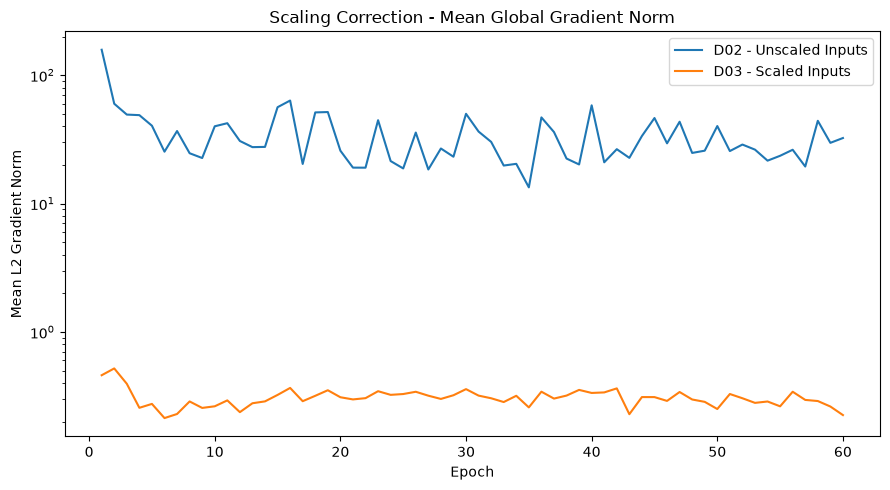

In [76]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    d02_history["epoch"],
    d02_history["global_grad_mean"],
    label="D02 - Unscaled Inputs",
)

ax.plot(
    d03_history["epoch"],
    d03_history["global_grad_mean"],
    label="D03 - Scaled Inputs",
)

ax.set_title(
    "Scaling Correction - Mean Global Gradient Norm"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")

ax.set_yscale("log")

ax.legend()

plt.tight_layout()
plt.show()

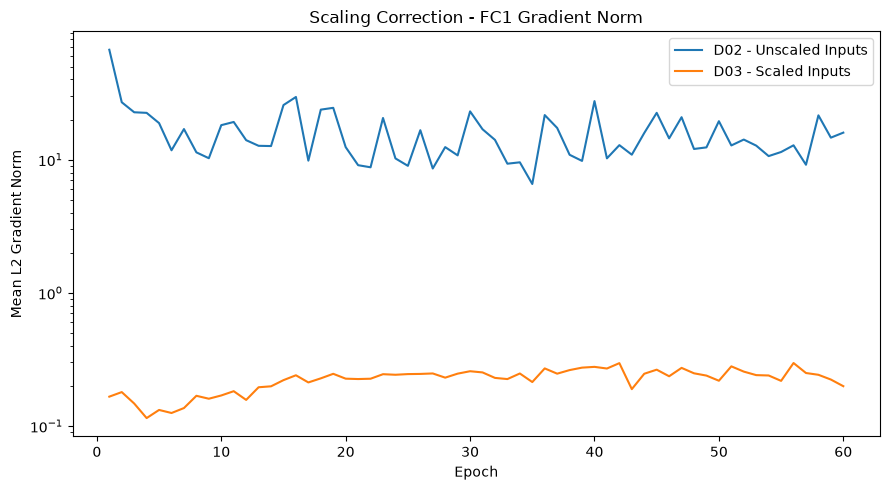

In [77]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    d02_history["epoch"],
    d02_history["fc1_grad_mean"],
    label="D02 - Unscaled Inputs",
)

ax.plot(
    d03_history["epoch"],
    d03_history["fc1_grad_mean"],
    label="D03 - Scaled Inputs",
)

ax.set_title(
    "Scaling Correction - FC1 Gradient Norm"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")

ax.set_yscale("log")

ax.legend()

plt.tight_layout()
plt.show()

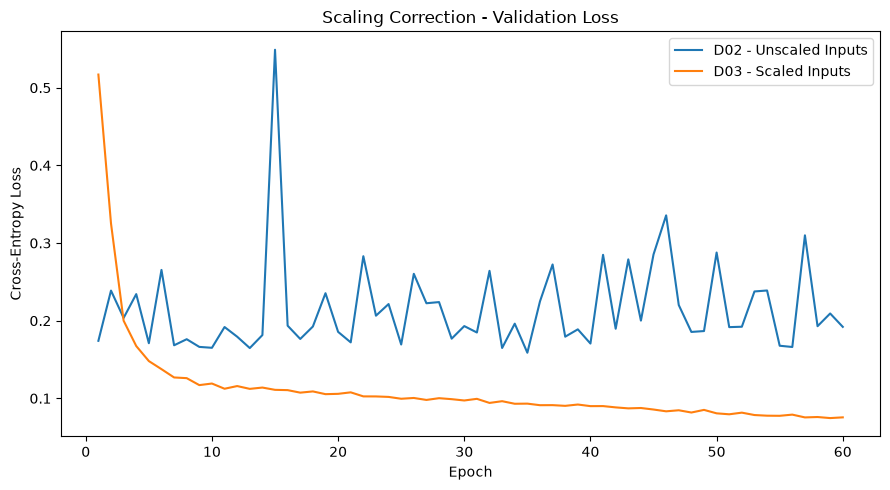

In [78]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    d02_history["epoch"],
    d02_history["val_loss"],
    label="D02 - Unscaled Inputs",
)

ax.plot(
    d03_history["epoch"],
    d03_history["val_loss"],
    label="D03 - Scaled Inputs",
)

ax.set_title(
    "Scaling Correction - Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")

ax.legend()

plt.tight_layout()
plt.show()

In [79]:
def summarize_scaling_diagnostic(
    experiment_name,
    history,
):
    best_index = history["val_loss"].idxmin()
    best_row = history.loc[best_index]

    return {
        "experiment": experiment_name,
        "initial_global_grad_mean": (
            history.iloc[0]["global_grad_mean"]
        ),
        "initial_global_grad_max": (
            history.iloc[0]["global_grad_max"]
        ),
        "maximum_global_grad": (
            history["global_grad_max"].max()
        ),
        "mean_global_grad": (
            history["global_grad_mean"].mean()
        ),
        "initial_fc1_grad_mean": (
            history.iloc[0]["fc1_grad_mean"]
        ),
        "maximum_fc1_grad": (
            history["fc1_grad_max"].max()
        ),
        "mean_fc1_grad": (
            history["fc1_grad_mean"].mean()
        ),
        "best_val_loss": (
            best_row["val_loss"]
        ),
        "best_val_f1": (
            best_row["val_f1"]
        ),
    }


scaling_diagnostic_comparison = pd.DataFrame([
    summarize_scaling_diagnostic(
        "D02 - Unscaled",
        d02_history,
    ),
    summarize_scaling_diagnostic(
        "D03 - Standardized",
        d03_history,
    ),
])

display(
    scaling_diagnostic_comparison.round(6)
)

,experiment,initial_global_grad_mean,initial_global_grad_max,maximum_global_grad,mean_global_grad,initial_fc1_grad_mean,maximum_fc1_grad,mean_fc1_grad,best_val_loss,best_val_f1
0,D02 - Unscaled,157.720374,318.469465,318.469465,34.571530,66.798657,134.351562,16.159374,0.158745,0.964539
1,D03 - Standardized,0.459977,0.664317,1.360599,0.308002,0.166152,1.243952,0.224300,0.074565,0.972222


In [80]:
d02_initial_global = (
    d02_history.iloc[0]["global_grad_mean"]
)

d03_initial_global = (
    d03_history.iloc[0]["global_grad_mean"]
)

d02_initial_fc1 = (
    d02_history.iloc[0]["fc1_grad_mean"]
)

d03_initial_fc1 = (
    d03_history.iloc[0]["fc1_grad_mean"]
)

global_gradient_reduction = (
    1.0
    - d03_initial_global
    / d02_initial_global
)

fc1_gradient_reduction = (
    1.0
    - d03_initial_fc1
    / d02_initial_fc1
)

print(
    "Initial global gradient reduction: "
    f"{global_gradient_reduction:.2%}"
)

print(
    "Initial FC1 gradient reduction: "
    f"{fc1_gradient_reduction:.2%}"
)

print(
    "\nInitial global gradient ratio "
    "(unscaled / scaled): "
    f"{d02_initial_global / d03_initial_global:.2f}x"
)

print(
    "Initial FC1 gradient ratio "
    "(unscaled / scaled): "
    f"{d02_initial_fc1 / d03_initial_fc1:.2f}x"
)

Initial global gradient reduction: 99.71%
Initial FC1 gradient reduction: 99.75%

Initial global gradient ratio (unscaled / scaled): 342.89x
Initial FC1 gradient ratio (unscaled / scaled): 402.03x


## Seleção do modelo final de classificação

A configuração final foi escolhida exclusivamente a partir dos resultados de validação, antes de qualquer avaliação no conjunto de teste. C01 e C06 apresentaram os maiores valores de F1 de validação, aproximadamente 0,9861, mas o scheduler utilizado em C06 não produziu melhora mensurável em relação à configuração de learning rate fixo. C02 apresentou uma loss de validação menor, porém seu F1 foi ligeiramente inferior e a convergência exigiu mais épocas.

Como técnicas adicionais como BatchNorm, Dropout, inicialização He e learning rate scheduling não produziram ganho de desempenho, C01 foi selecionado como modelo final. Essa escolha também privilegia uma arquitetura mais simples, mantendo ReLU, inicialização padrão do PyTorch, AdamW e duas camadas ocultas com 64 e 32 unidades.

In [81]:
final_classification_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=2,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

final_classification_model.load_state_dict(
    torch.load(
        c01_checkpoint,
        map_location=DEVICE,
        weights_only=True,
    )
)

final_classification_model = (
    final_classification_model.to(DEVICE)
)

final_classification_model.eval()

print(
    "Best classification checkpoint "
    "loaded successfully."
)

print(
    f"Checkpoint: {c01_checkpoint}"
)

Best classification checkpoint loaded successfully.
Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\classification_c01_relu_default_best.pt


In [82]:
def collect_classification_predictions(
    model,
    loader,
):
    model.eval()

    all_targets = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for features, targets in loader:
            features = features.to(DEVICE)

            logits = model(features)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = logits.argmax(
                dim=1
            )

            all_targets.extend(
                targets.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.asarray(all_targets),
        np.asarray(all_predictions),
        np.asarray(all_probabilities),
    )


_, c01_reload_predictions, _ = (
    collect_classification_predictions(
        final_classification_model,
        val_loader,
    )
)

_, c01_original_predictions, _ = (
    collect_classification_predictions(
        c01_model,
        val_loader,
    )
)

predictions_match = np.array_equal(
    c01_reload_predictions,
    c01_original_predictions,
)

print(
    f"Reloaded predictions match "
    f"original predictions: "
    f"{predictions_match}"
)

Reloaded predictions match original predictions: True


## Avaliação final da classificação

O conjunto de teste é utilizado somente nesta etapa, depois da seleção definitiva da arquitetura e dos hiperparâmetros, a MLP será comparada à Regressão Logística utilizada como baseline.

Serão calculadas accuracy, precision, recall e F1 e também será construída a matriz de confusão para identificar quais tipos de erro permanecem no modelo final e investigar se esses erros estão associados a amostras próximas ao limiar utilizado para transformar `Heating Load` em classes.

In [83]:
from sklearn.metrics import confusion_matrix

In [84]:
_, final_test_predictions, final_test_probabilities = (
    collect_classification_predictions(
        final_classification_model,
        test_loader,
    )
)

final_test_metrics = {
    "accuracy": accuracy_score(
        y_test_class,
        final_test_predictions,
    ),
    "precision": precision_score(
        y_test_class,
        final_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test_class,
        final_test_predictions,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test_class,
        final_test_predictions,
        zero_division=0,
    ),
}

classification_baseline_test_predictions = (
    classification_baseline.predict(
        X_test_processed
    )
)

classification_baseline_test_metrics = {
    "accuracy": accuracy_score(
        y_test_class,
        classification_baseline_test_predictions,
    ),
    "precision": precision_score(
        y_test_class,
        classification_baseline_test_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test_class,
        classification_baseline_test_predictions,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test_class,
        classification_baseline_test_predictions,
        zero_division=0,
    ),
}

classification_test_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        **classification_baseline_test_metrics,
    },
    {
        "model": "MLP C01",
        **final_test_metrics,
    },
])

display(
    classification_test_comparison.round(6)
)

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.931034,1.0,0.870968,0.931034
1,MLP C01,0.982759,1.0,0.967742,0.983607


In [85]:
final_confusion_matrix = confusion_matrix(
    y_test_class,
    final_test_predictions,
)

display(
    pd.DataFrame(
        final_confusion_matrix,
        index=[
            "True Low Demand",
            "True High Demand",
        ],
        columns=[
            "Predicted Low Demand",
            "Predicted High Demand",
        ],
    )
)

,Predicted Low Demand,Predicted High Demand
True Low Demand,54,0
True High Demand,2,60


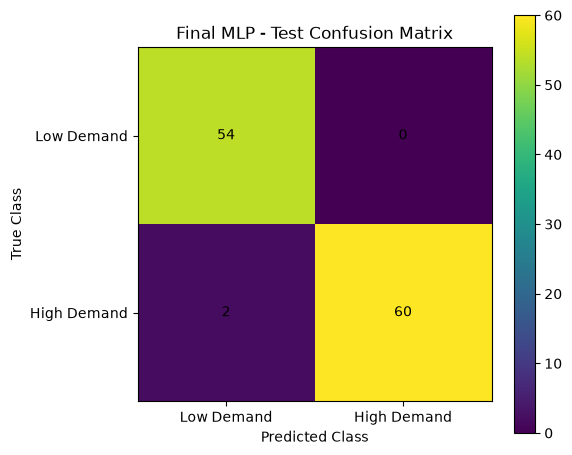

Confusion matrix saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\classification_confusion_matrix.png


In [86]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    final_confusion_matrix,
)

for row in range(
    final_confusion_matrix.shape[0]
):
    for column in range(
        final_confusion_matrix.shape[1]
    ):
        ax.text(
            column,
            row,
            final_confusion_matrix[
                row,
                column,
            ],
            ha="center",
            va="center",
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Low Demand",
    "High Demand",
])

ax.set_yticklabels([
    "Low Demand",
    "High Demand",
])

ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_title(
    "Final MLP - Test Confusion Matrix"
)

fig.colorbar(
    image,
    ax=ax,
)

plt.tight_layout()

confusion_matrix_path = (
    ARTIFACTS_DIR
    / "classification_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Confusion matrix saved to: "
    f"{confusion_matrix_path}"
)

In [87]:
classification_error_analysis = pd.DataFrame({
    "heating_load": (
        y_test["heating_load"].to_numpy()
    ),
    "true_class": (
        y_test_class.to_numpy()
    ),
    "predicted_class": (
        final_test_predictions
    ),
})

classification_error_analysis[
    "distance_to_threshold"
] = np.abs(
    classification_error_analysis[
        "heating_load"
    ]
    - classification_threshold
)

classification_error_analysis[
    "is_error"
] = (
    classification_error_analysis[
        "true_class"
    ]
    != classification_error_analysis[
        "predicted_class"
    ]
)

errors = classification_error_analysis[
    classification_error_analysis[
        "is_error"
    ]
].copy()

correct_predictions = (
    classification_error_analysis[
        ~classification_error_analysis[
            "is_error"
        ]
    ].copy()
)

print(
    f"Number of test errors: "
    f"{len(errors)}"
)

if len(errors) > 0:
    print(
        "Mean distance to threshold "
        "for errors: "
        f"{errors['distance_to_threshold'].mean():.4f}"
    )

    print(
        "Median distance to threshold "
        "for errors: "
        f"{errors['distance_to_threshold'].median():.4f}"
    )

    print(
        "Mean distance to threshold "
        "for correct predictions: "
        f"{correct_predictions['distance_to_threshold'].mean():.4f}"
    )

    display(
        errors.sort_values(
            "distance_to_threshold"
        )
    )

Number of test errors: 2
Mean distance to threshold for errors: 0.1950
Median distance to threshold for errors: 0.1950
Mean distance to threshold for correct predictions: 8.9058


,heating_load,true_class,predicted_class,distance_to_threshold,is_error
48,17.35,1,0,0.12,True
81,17.50,1,0,0.27,True


In [88]:
classification_results_path = (
    ARTIFACTS_DIR
    / "classification_test_results.csv"
)

classification_test_comparison.to_csv(
    classification_results_path,
    index=False,
)

classification_error_path = (
    ARTIFACTS_DIR
    / "classification_error_analysis.csv"
)

classification_error_analysis.to_csv(
    classification_error_path,
    index=False,
)

print(
    f"Test results saved to: "
    f"{classification_results_path}"
)

print(
    f"Error analysis saved to: "
    f"{classification_error_path}"
)

Test results saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\classification_test_results.csv
Error analysis saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\classification_error_analysis.csv


### Efeito medido da correção de estabilidade

O experimento D02 confirmou que a diferença de escala entre as variáveis de entrada produzia gradientes excessivamente elevados e treinamento instável quando os valores numéricos eram utilizados diretamente. Ao restaurar a padronização em D03, mantendo arquitetura, inicialização, otimizador, learning rate e número de épocas constantes, o gradient norm global médio da primeira época caiu de aproximadamente 157,72 para 0,46, uma redução de 99,71%. Na primeira camada, a redução foi de aproximadamente 66,80 para 0,17, equivalente a 99,75%.

Em termos relativos, os gradientes iniciais globais eram aproximadamente 343 vezes maiores sem padronização, enquanto na primeira camada a diferença chegava a aproximadamente 402 vezes. A correção também melhorou a melhor loss de validação de aproximadamente 0,1587 para 0,0746.

Esse resultado fornece evidência objetiva de que as escalas originais das características provocavam instabilidade compatível com exploding gradients. A hipótese formulada antes da correção foi confirmada e a padronização mostrou-se necessária não apenas como etapa convencional de pré-processamento, mas como mecanismo fundamental para estabilizar a otimização desta MLP.

### Resultado final da classificação

No conjunto de teste, a MLP selecionada alcançou accuracy de aproximadamente 0,9828 e F1 de 0,9836, superando o baseline de Regressão Logística, que apresentou aproximadamente 0,9310 para ambas as métricas. A matriz de confusão registrou 54 amostras corretamente classificadas como baixa demanda, 60 corretamente classificadas como alta demanda, nenhum falso positivo e apenas dois falsos negativos.

Os dois erros ocorreram em edifícios com `Heating Load` de 17,35 e 17,50, valores apenas 0,12 e 0,27 acima do limiar de classificação de 17,23 e a distância média dos erros até esse limiar foi 0,195, enquanto as previsões corretas apresentaram distância média de aproximadamente 8,91.

Esse padrão sustenta a hipótese de que os erros restantes estão associados principalmente à discretização de um alvo originalmente contínuo. Amostras situadas imediatamente acima do limiar possuem características energéticas muito próximas às da classe inferior, tornando a fronteira entre as duas categorias naturalmente mais ambígua. Portanto, os erros observados não indicam confusão generalizada entre as classes, mas concentram-se na região em que a transformação de regressão para classificação introduziu uma fronteira artificial.

## Variante de regressão

O dataset Energy Efficiency é originalmente um problema de regressão, pois `Heating Load` representa uma quantidade contínua, após utilizar esse alvo para construir a formulação binária de classificação, o pipeline será adaptado para prever diretamente seu valor numérico. A regressão reutiliza exatamente a mesma divisão entre treino, validação e teste e o mesmo pré-processamento das características. E a arquitetura mantém duas camadas ocultas com 64 e 32 unidades, mas a camada de saída passa a possuir um único neurônio sem função de ativação, permitindo produzir qualquer valor contínuo.

### Arquitetura e estratégia de treinamento da regressão

A arquitetura rasa utilizada na classificação será mantida porque os experimentos anteriores mostraram que aumentar a profundidade não trouxe benefício para este conjunto de dados. ReLU e a inicialização padrão também serão preservadas, uma vez que a configuração simples apresentou treinamento estável e bom desempenho de validação.

A otimização utilizará AdamW e `ReduceLROnPlateau`, monitorando a MSE de validação. Neste caso, o scheduler será utilizado como parte do pipeline profissional de treinamento e poderá reduzir o learning rate quando a otimização atingir um plateau, Gradient norms continuarão sendo registrados para permitir verificar se a mudança da tarefa de classificação para regressão altera a estabilidade do treinamento.

In [89]:
def evaluate_regressor(
    model,
    loader,
    criterion,
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            predictions = model(features)

            loss = criterion(
                predictions,
                targets,
            )

            batch_size = features.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            total_samples += batch_size

            all_targets.extend(
                targets.cpu().numpy().ravel()
            )

            all_predictions.extend(
                predictions.cpu().numpy().ravel()
            )

    average_loss = (
        running_loss
        / total_samples
    )

    all_targets = np.asarray(
        all_targets
    )

    all_predictions = np.asarray(
        all_predictions
    )

    mae = mean_absolute_error(
        all_targets,
        all_predictions,
    )

    rmse = np.sqrt(
        mean_squared_error(
            all_targets,
            all_predictions,
        )
    )

    r2 = r2_score(
        all_targets,
        all_predictions,
    )

    return {
        "loss": average_loss,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    }

In [90]:
def train_regressor(
    model,
    experiment_name,
    epochs=400,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=True,
    early_stopping_patience=50,
):
    reset_random_seeds()

    train_loader, val_loader, _ = create_dataloaders(
        "regression"
    )

    model = model.to(DEVICE)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = None

    if use_scheduler:
        scheduler = (
            torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=12,
                min_lr=1e-6,
            )
        )

    run_dir = (
        RUNS_DIR
        / "project_1"
        / "regression"
        / experiment_name
    )

    if run_dir.exists():
        shutil.rmtree(run_dir)

    writer = SummaryWriter(
        log_dir=run_dir
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"regression_{experiment_name}_best.pt"
    )

    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    history = []

    for epoch in range(
        1,
        epochs + 1,
    ):
        model.train()

        running_train_loss = 0.0
        total_train_samples = 0

        global_gradient_norms = []
        fc1_gradient_norms = []
        fc2_gradient_norms = []
        output_gradient_norms = []

        train_targets = []
        train_predictions = []

        for features, targets in train_loader:
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            predictions = model(features)

            loss = criterion(
                predictions,
                targets,
            )

            loss.backward()

            global_norm, layer_norms = (
                compute_gradient_norms(model)
            )

            global_gradient_norms.append(
                global_norm
            )

            fc1_gradient_norms.append(
                layer_norms["fc1.weight"]
            )

            fc2_gradient_norms.append(
                layer_norms["fc2.weight"]
            )

            output_gradient_norms.append(
                layer_norms["output.weight"]
            )

            optimizer.step()

            batch_size = features.size(0)

            running_train_loss += (
                loss.item()
                * batch_size
            )

            total_train_samples += batch_size

            train_targets.extend(
                targets.detach()
                .cpu()
                .numpy()
                .ravel()
            )

            train_predictions.extend(
                predictions.detach()
                .cpu()
                .numpy()
                .ravel()
            )

        train_loss = (
            running_train_loss
            / total_train_samples
        )

        train_mae = mean_absolute_error(
            train_targets,
            train_predictions,
        )

        train_rmse = np.sqrt(
            mean_squared_error(
                train_targets,
                train_predictions,
            )
        )

        train_r2 = r2_score(
            train_targets,
            train_predictions,
        )

        validation_metrics = (
            evaluate_regressor(
                model,
                val_loader,
                criterion,
            )
        )

        val_loss = validation_metrics["loss"]

        if scheduler is not None:
            scheduler.step(
                val_loss
            )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        mean_global_gradient_norm = float(
            np.mean(
                global_gradient_norms
            )
        )

        max_global_gradient_norm = float(
            np.max(
                global_gradient_norms
            )
        )

        mean_fc1_gradient_norm = float(
            np.mean(
                fc1_gradient_norms
            )
        )

        mean_fc2_gradient_norm = float(
            np.mean(
                fc2_gradient_norms
            )
        )

        mean_output_gradient_norm = float(
            np.mean(
                output_gradient_norms
            )
        )

        writer.add_scalars(
            "Loss",
            {
                "train": train_loss,
                "validation": val_loss,
            },
            epoch,
        )

        writer.add_scalars(
            "MAE",
            {
                "train": train_mae,
                "validation": validation_metrics[
                    "mae"
                ],
            },
            epoch,
        )

        writer.add_scalar(
            "RMSE/validation",
            validation_metrics["rmse"],
            epoch,
        )

        writer.add_scalar(
            "R2/validation",
            validation_metrics["r2"],
            epoch,
        )

        writer.add_scalar(
            "LearningRate",
            current_learning_rate,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_mean",
            mean_global_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/global_max",
            max_global_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/fc1",
            mean_fc1_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/fc2",
            mean_fc2_gradient_norm,
            epoch,
        )

        writer.add_scalar(
            "GradientNorm/output",
            mean_output_gradient_norm,
            epoch,
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_mae": train_mae,
            "val_mae": validation_metrics[
                "mae"
            ],
            "train_rmse": train_rmse,
            "val_rmse": validation_metrics[
                "rmse"
            ],
            "train_r2": train_r2,
            "val_r2": validation_metrics[
                "r2"
            ],
            "learning_rate": (
                current_learning_rate
            ),
            "grad_global_mean": (
                mean_global_gradient_norm
            ),
            "grad_global_max": (
                max_global_gradient_norm
            ),
            "grad_fc1": (
                mean_fc1_gradient_norm
            ),
            "grad_fc2": (
                mean_fc2_gradient_norm
            ),
            "grad_output": (
                mean_output_gradient_norm
            ),
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 50 == 0
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train MSE: {train_loss:.4f} | "
                f"Val MSE: {val_loss:.4f} | "
                f"Val MAE: "
                f"{validation_metrics['mae']:.4f} | "
                f"Val R2: "
                f"{validation_metrics['r2']:.4f} | "
                f"Grad Norm: "
                f"{mean_global_gradient_norm:.4f} | "
                f"LR: "
                f"{current_learning_rate:.6f}"
            )

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                f"Early stopping at epoch "
                f"{epoch}."
            )
            break

    writer.close()

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True,
        )
    )

    best_validation_metrics = (
        evaluate_regressor(
            model,
            val_loader,
            criterion,
        )
    )

    print(
        f"\nBest epoch: {best_epoch}"
    )

    print(
        f"Best validation MSE: "
        f"{best_val_loss:.4f}"
    )

    print(
        f"Best validation MAE: "
        f"{best_validation_metrics['mae']:.4f}"
    )

    print(
        f"Best validation RMSE: "
        f"{best_validation_metrics['rmse']:.4f}"
    )

    print(
        f"Best validation R2: "
        f"{best_validation_metrics['r2']:.4f}"
    )

    return (
        model,
        pd.DataFrame(history),
        checkpoint_path,
        best_validation_metrics,
    )

In [91]:
reset_random_seeds()

regression_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=1,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

(
    regression_model,
    regression_history,
    regression_checkpoint,
    regression_validation_metrics,
) = train_regressor(
    model=regression_model,
    experiment_name="r01_relu_default",
    epochs=400,
    learning_rate=1e-3,
    weight_decay=1e-4,
    use_scheduler=True,
    early_stopping_patience=50,
)

display(
    regression_history.tail()
)

print(
    f"\nCheckpoint: "
    f"{regression_checkpoint}"
)

print(
    "\nValidation metrics:"
)

for metric_name, metric_value in (
    regression_validation_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

Epoch 001 | Train MSE: 581.6739 | Val MSE: 660.6729 | Val MAE: 23.6346 | Val R2: -5.4636 | Grad Norm: 70.2241 | LR: 0.001000
Epoch 050 | Train MSE: 6.1926 | Val MSE: 8.2365 | Val MAE: 1.9673 | Val R2: 0.9194 | Grad Norm: 18.5179 | LR: 0.001000
Epoch 100 | Train MSE: 4.2618 | Val MSE: 6.1957 | Val MAE: 1.7592 | Val R2: 0.9394 | Grad Norm: 24.6183 | LR: 0.001000
Epoch 150 | Train MSE: 1.9344 | Val MSE: 3.0263 | Val MAE: 1.2989 | Val R2: 0.9704 | Grad Norm: 12.9445 | LR: 0.001000
Epoch 200 | Train MSE: 0.6101 | Val MSE: 0.9909 | Val MAE: 0.7449 | Val R2: 0.9903 | Grad Norm: 9.6091 | LR: 0.001000
Epoch 250 | Train MSE: 0.2501 | Val MSE: 0.4914 | Val MAE: 0.5342 | Val R2: 0.9952 | Grad Norm: 7.4952 | LR: 0.001000
Epoch 300 | Train MSE: 0.1564 | Val MSE: 0.3851 | Val MAE: 0.4791 | Val R2: 0.9962 | Grad Norm: 6.0365 | LR: 0.001000
Epoch 350 | Train MSE: 0.1237 | Val MSE: 0.3274 | Val MAE: 0.4409 | Val R2: 0.9968 | Grad Norm: 7.3427 | LR: 0.000500
Epoch 400 | Train MSE: 0.1068 | Val MSE: 0.317

,epoch,train_loss,val_loss,train_mae,val_mae,train_rmse,val_rmse,train_r2,val_r2,learning_rate,grad_global_mean,grad_global_max,grad_fc1,grad_fc2,grad_output
395,396,0.104641,0.317019,0.230086,0.430406,0.323483,0.563044,0.998970,0.996899,0.00025,4.418125,9.231665,2.307401,1.532539,3.149856
396,397,0.108950,0.314565,0.232799,0.428995,0.330076,0.560861,0.998927,0.996922,0.00025,5.123046,8.666080,2.666303,1.800610,3.665858
397,398,0.105923,0.315703,0.229163,0.430628,0.325457,0.561875,0.998957,0.996911,0.00025,5.983986,14.335276,2.432120,1.922742,4.914213
398,399,0.108175,0.330840,0.232459,0.444696,0.328900,0.575187,0.998935,0.996763,0.00025,5.292020,12.260788,2.553297,1.747430,4.021844
399,400,0.106815,0.317316,0.231860,0.432362,0.326826,0.563308,0.998948,0.996896,0.00025,4.745944,11.550705,2.677953,1.753182,3.096380



Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\regression_r01_relu_default_best.pt

Validation metrics:
loss: 0.3146
mae: 0.4290
rmse: 0.5609
r2: 0.9969


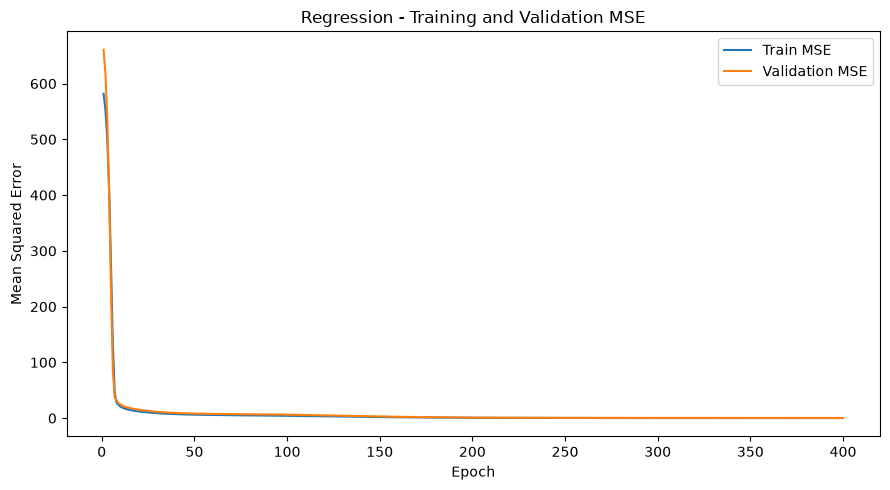

In [92]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    regression_history["epoch"],
    regression_history["train_loss"],
    label="Train MSE",
)

ax.plot(
    regression_history["epoch"],
    regression_history["val_loss"],
    label="Validation MSE",
)

ax.set_title(
    "Regression - Training and Validation MSE"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend()

plt.tight_layout()
plt.show()

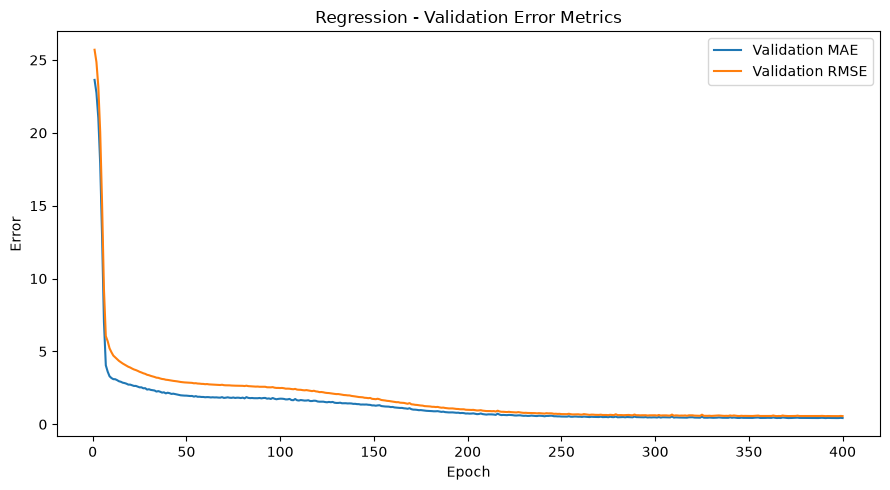

In [93]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    regression_history["epoch"],
    regression_history["val_mae"],
    label="Validation MAE",
)

ax.plot(
    regression_history["epoch"],
    regression_history["val_rmse"],
    label="Validation RMSE",
)

ax.set_title(
    "Regression - Validation Error Metrics"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Error")
ax.legend()

plt.tight_layout()
plt.show()

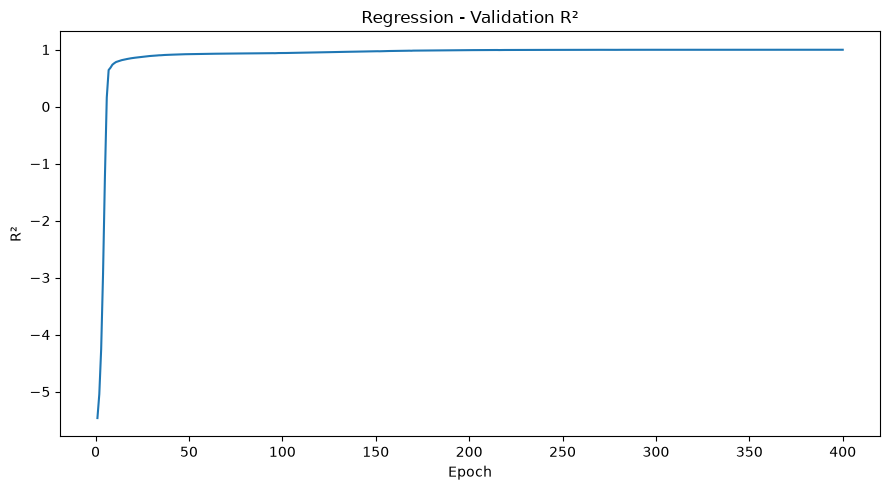

In [94]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    regression_history["epoch"],
    regression_history["val_r2"],
)

ax.set_title(
    "Regression - Validation R²"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("R²")

plt.tight_layout()
plt.show()

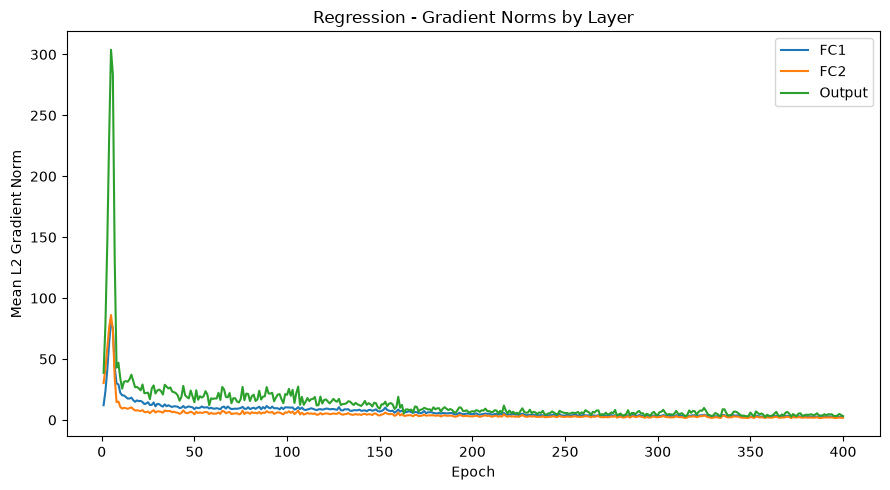

In [95]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    regression_history["epoch"],
    regression_history["grad_fc1"],
    label="FC1",
)

ax.plot(
    regression_history["epoch"],
    regression_history["grad_fc2"],
    label="FC2",
)

ax.plot(
    regression_history["epoch"],
    regression_history["grad_output"],
    label="Output",
)

ax.set_title(
    "Regression - Gradient Norms by Layer"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean L2 Gradient Norm")
ax.legend()

plt.tight_layout()
plt.show()

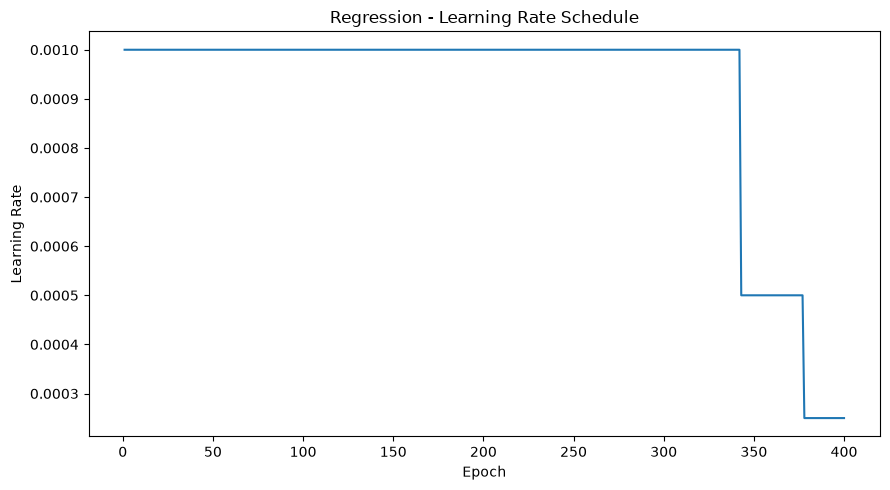

In [96]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    regression_history["epoch"],
    regression_history[
        "learning_rate"
    ],
)

ax.set_title(
    "Regression - Learning Rate Schedule"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")

plt.tight_layout()
plt.show()

### Análise do treinamento da regressão

A variante de regressão apresentou convergência progressiva ao longo das 400 épocas. A MSE de validação caiu de aproximadamente 660,67 na primeira época para 0,3146 no melhor checkpoint, encontrado na época 397. Nesse ponto, o modelo apresentou MAE de aproximadamente 0,4290, RMSE de 0,5609 e R² de 0,9969 no conjunto de validação.

As curvas indicam convergência estável, embora a loss de treino tenha permanecido inferior à de validação no estágio final, esse pequeno gap de generalização é esperado e não apresentou crescimento suficiente para caracterizar overfitting severo e o desempenho de validação continuou melhorando até as últimas épocas.

O scheduler também foi acionado durante a fase final do treinamento, reduzindo o learning rate inicialmente configurado em 0,001. Após essas reduções, a validação continuou apresentando pequenas melhorias, chegando ao melhor resultado com learning rate de 0,00025, comportamento compatível com um refinamento dos parâmetros quando o modelo já se encontrava próximo da convergência.

Os gradient norms permaneceram finitos e controlados durante essa fase. Embora a regressão apresente gradientes naturalmente maiores que a classificação devido à escala da MSE e do alvo contínuo, não foram observados valores comparáveis à instabilidade extrema produzida pelo experimento D02 com entradas não padronizadas.

## Avaliação final da regressão

A configuração da regressão é considerada definitiva a partir deste ponto. Assim como na classificação, o melhor checkpoint será carregado em uma nova instância da MLP antes da avaliação final, demonstrando que o `state_dict` armazenado é suficiente para reproduzir as predições do modelo selecionado.

O conjunto de teste será utilizado e o desempenho da MLP será comparado ao baseline Ridge Regression por meio das métricas MAE, RMSE e R². A análise também incluirá as relações entre valores reais e previstos e a distribuição dos resíduos, permitindo verificar se os erros apresentam algum padrão sistemático em relação à magnitude de `Heating Load`.

In [97]:
regression_train_loader, regression_val_loader, regression_test_loader = (
    create_dataloaders(
        "regression"
    )
)

print(
    f"Regression training batches: "
    f"{len(regression_train_loader)}"
)

print(
    f"Regression validation batches: "
    f"{len(regression_val_loader)}"
)

print(
    f"Regression test batches: "
    f"{len(regression_test_loader)}"
)

Regression training batches: 17
Regression validation batches: 4
Regression test batches: 4


In [98]:
final_regression_model = EnergyMLP(
    input_dim=INPUT_DIM,
    output_dim=1,
    activation_name="relu",
    use_batch_norm=False,
    dropout_rate=0.0,
    initialization="default",
)

final_regression_model.load_state_dict(
    torch.load(
        regression_checkpoint,
        map_location=DEVICE,
        weights_only=True,
    )
)

final_regression_model = (
    final_regression_model.to(DEVICE)
)

final_regression_model.eval()

print(
    "Best regression checkpoint "
    "loaded successfully."
)

print(
    f"Checkpoint: "
    f"{regression_checkpoint}"
)

Best regression checkpoint loaded successfully.
Checkpoint: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\checkpoints\regression_r01_relu_default_best.pt


In [99]:
def collect_regression_predictions(
    model,
    loader,
):
    model.eval()

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in loader:
            features = features.to(DEVICE)

            predictions = model(
                features
            )

            all_targets.extend(
                targets.numpy().ravel()
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
                .ravel()
            )

    return (
        np.asarray(all_targets),
        np.asarray(all_predictions),
    )

In [100]:
(
    validation_targets,
    original_regression_predictions,
) = collect_regression_predictions(
    regression_model,
    regression_val_loader,
)

(
    reloaded_validation_targets,
    reloaded_regression_predictions,
) = collect_regression_predictions(
    final_regression_model,
    regression_val_loader,
)

targets_match = np.array_equal(
    validation_targets,
    reloaded_validation_targets,
)

predictions_match = np.allclose(
    original_regression_predictions,
    reloaded_regression_predictions,
    rtol=1e-6,
    atol=1e-6,
)

maximum_prediction_difference = np.max(
    np.abs(
        original_regression_predictions
        - reloaded_regression_predictions
    )
)

print(
    f"Validation targets match: "
    f"{targets_match}"
)

print(
    f"Reloaded predictions match: "
    f"{predictions_match}"
)

print(
    "Maximum absolute prediction difference: "
    f"{maximum_prediction_difference:.10f}"
)

Validation targets match: True
Reloaded predictions match: True
Maximum absolute prediction difference: 0.0000000000


In [101]:
regression_test_criterion = nn.MSELoss()

final_regression_test_metrics = (
    evaluate_regressor(
        final_regression_model,
        regression_test_loader,
        regression_test_criterion,
    )
)

print(
    "Final MLP test metrics:"
)

for metric_name, metric_value in (
    final_regression_test_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.6f}"
    )

Final MLP test metrics:
loss: 0.274841
mae: 0.390909
rmse: 0.524253
r2: 0.997194


In [102]:
ridge_test_predictions = (
    regression_baseline.predict(
        X_test_processed
    )
)

ridge_test_mae = mean_absolute_error(
    y_test["heating_load"],
    ridge_test_predictions,
)

ridge_test_rmse = np.sqrt(
    mean_squared_error(
        y_test["heating_load"],
        ridge_test_predictions,
    )
)

ridge_test_r2 = r2_score(
    y_test["heating_load"],
    ridge_test_predictions,
)

regression_test_comparison = pd.DataFrame([
    {
        "model": "Ridge Regression",
        "MAE": ridge_test_mae,
        "RMSE": ridge_test_rmse,
        "R2": ridge_test_r2,
    },
    {
        "model": "MLP",
        "MAE": final_regression_test_metrics[
            "mae"
        ],
        "RMSE": final_regression_test_metrics[
            "rmse"
        ],
        "R2": final_regression_test_metrics[
            "r2"
        ],
    },
])

display(
    regression_test_comparison.round(6)
)

,model,MAE,RMSE,R2
0,Ridge Regression,1.939044,2.668805,0.927286
1,MLP,0.390909,0.524253,0.997194


In [103]:
(
    regression_test_targets,
    regression_test_predictions,
) = collect_regression_predictions(
    final_regression_model,
    regression_test_loader,
)

regression_test_results = pd.DataFrame({
    "actual_heating_load": (
        regression_test_targets
    ),
    "predicted_heating_load": (
        regression_test_predictions
    ),
})

regression_test_results[
    "residual"
] = (
    regression_test_results[
        "actual_heating_load"
    ]
    - regression_test_results[
        "predicted_heating_load"
    ]
)

regression_test_results[
    "absolute_error"
] = np.abs(
    regression_test_results[
        "residual"
    ]
)

display(
    regression_test_results.head()
)

,actual_heating_load,predicted_heating_load,residual,absolute_error
0,24.940001,25.435537,-0.495537,0.495537
1,35.450001,36.356247,-0.906246,0.906246
2,28.070000,28.739359,-0.669359,0.669359
3,8.600000,8.300894,0.299107,0.299107
4,36.950001,36.587418,0.362583,0.362583


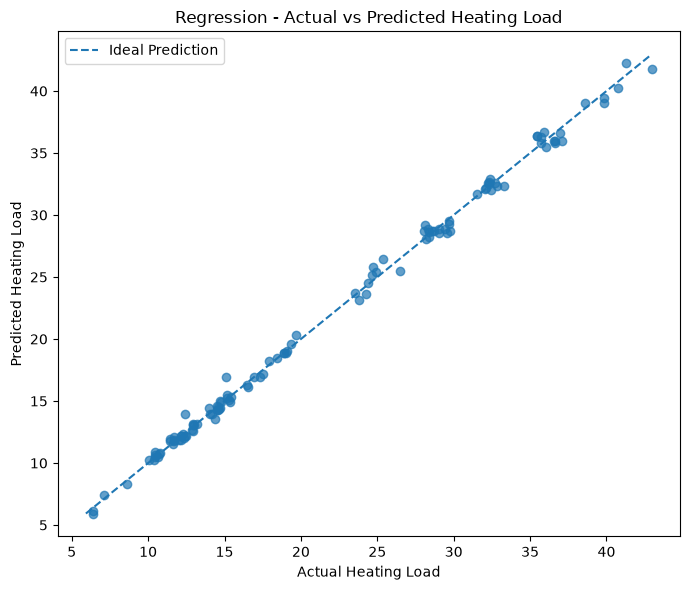

Prediction plot saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\regression_actual_vs_predicted.png


In [104]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    regression_test_results[
        "actual_heating_load"
    ],
    regression_test_results[
        "predicted_heating_load"
    ],
    alpha=0.7,
)

minimum_value = min(
    regression_test_results[
        "actual_heating_load"
    ].min(),
    regression_test_results[
        "predicted_heating_load"
    ].min(),
)

maximum_value = max(
    regression_test_results[
        "actual_heating_load"
    ].max(),
    regression_test_results[
        "predicted_heating_load"
    ].max(),
)

ax.plot(
    [
        minimum_value,
        maximum_value,
    ],
    [
        minimum_value,
        maximum_value,
    ],
    linestyle="--",
    label="Ideal Prediction",
)

ax.set_title(
    "Regression - Actual vs Predicted Heating Load"
)

ax.set_xlabel(
    "Actual Heating Load"
)

ax.set_ylabel(
    "Predicted Heating Load"
)

ax.legend()

plt.tight_layout()

regression_predictions_path = (
    ARTIFACTS_DIR
    / "regression_actual_vs_predicted.png"
)

plt.savefig(
    regression_predictions_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Prediction plot saved to: "
    f"{regression_predictions_path}"
)

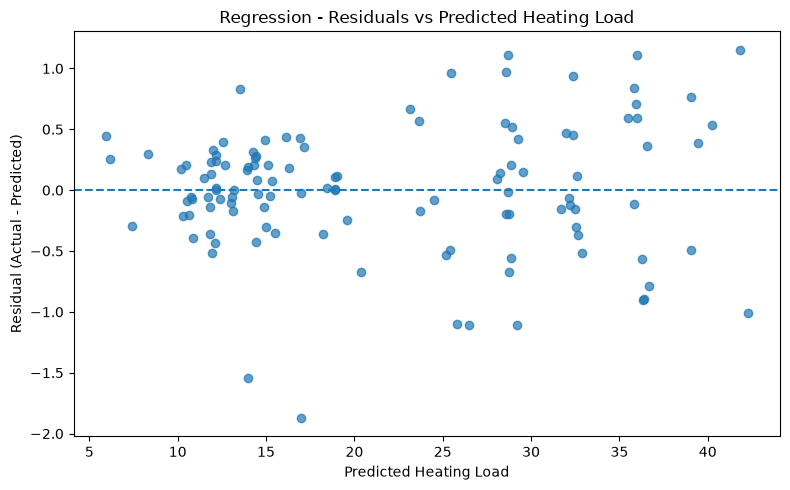

Residual plot saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\regression_residuals.png


In [105]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.scatter(
    regression_test_results[
        "predicted_heating_load"
    ],
    regression_test_results[
        "residual"
    ],
    alpha=0.7,
)

ax.axhline(
    y=0.0,
    linestyle="--",
)

ax.set_title(
    "Regression - Residuals vs Predicted Heating Load"
)

ax.set_xlabel(
    "Predicted Heating Load"
)

ax.set_ylabel(
    "Residual (Actual - Predicted)"
)

plt.tight_layout()

regression_residuals_path = (
    ARTIFACTS_DIR
    / "regression_residuals.png"
)

plt.savefig(
    regression_residuals_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    f"Residual plot saved to: "
    f"{regression_residuals_path}"
)

In [106]:
residual_summary = pd.DataFrame({
    "metric": [
        "mean_residual",
        "median_residual",
        "residual_std",
        "mean_absolute_error",
        "maximum_absolute_error",
    ],
    "value": [
        regression_test_results[
            "residual"
        ].mean(),
        regression_test_results[
            "residual"
        ].median(),
        regression_test_results[
            "residual"
        ].std(),
        regression_test_results[
            "absolute_error"
        ].mean(),
        regression_test_results[
            "absolute_error"
        ].max(),
    ],
})

display(
    residual_summary.round(6)
)

,metric,value
0,mean_residual,0.012657
1,median_residual,0.010200
2,residual_std,0.526374
3,mean_absolute_error,0.390909
4,maximum_absolute_error,1.872436


In [107]:
largest_regression_errors = (
    regression_test_results
    .sort_values(
        by="absolute_error",
        ascending=False,
    )
    .head(10)
    .reset_index(drop=True)
)

display(
    largest_regression_errors.round(4)
)

,actual_heating_load,predicted_heating_load,residual,absolute_error
0,15.090000,16.962400,-1.8724,1.8724
1,12.430000,13.973700,-1.5437,1.5437
2,42.959999,41.806301,1.1537,1.1537
3,29.790001,28.676100,1.1139,1.1139
4,37.099998,35.987499,1.1125,1.1125
5,25.360001,26.468500,-1.1085,1.1085
6,28.090000,29.197901,-1.1079,1.1079
7,24.700001,25.800200,-1.1002,1.1002
8,41.259998,42.270699,-1.0107,1.0107
9,29.540001,28.569000,0.9710,0.9710


In [108]:
regression_results_path = (
    ARTIFACTS_DIR
    / "regression_test_results.csv"
)

regression_comparison_path = (
    ARTIFACTS_DIR
    / "regression_model_comparison.csv"
)

regression_test_results.to_csv(
    regression_results_path,
    index=False,
)

regression_test_comparison.to_csv(
    regression_comparison_path,
    index=False,
)

print(
    f"Regression predictions saved to: "
    f"{regression_results_path}"
)

print(
    f"Regression comparison saved to: "
    f"{regression_comparison_path}"
)

Regression predictions saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\regression_test_results.csv
Regression comparison saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\regression_model_comparison.csv


In [109]:
project_1_final_results = pd.DataFrame([
    {
        "task": "Classification",
        "model": "Logistic Regression",
        "primary_metric": "F1",
        "value": (
            classification_baseline_test_metrics[
                "f1"
            ]
        ),
    },
    {
        "task": "Classification",
        "model": "MLP",
        "primary_metric": "F1",
        "value": final_test_metrics[
            "f1"
        ],
    },
    {
        "task": "Regression",
        "model": "Ridge Regression",
        "primary_metric": "RMSE",
        "value": ridge_test_rmse,
    },
    {
        "task": "Regression",
        "model": "MLP",
        "primary_metric": "RMSE",
        "value": (
            final_regression_test_metrics[
                "rmse"
            ]
        ),
    },
])

display(
    project_1_final_results.round(6)
)

project_1_final_results_path = (
    ARTIFACTS_DIR
    / "project_1_final_results.csv"
)

project_1_final_results.to_csv(
    project_1_final_results_path,
    index=False,
)

print(
    f"\nFinal summary saved to: "
    f"{project_1_final_results_path}"
)

,task,model,primary_metric,value
0,Classification,Logistic Regression,F1,0.931034
1,Classification,MLP,F1,0.983607
2,Regression,Ridge Regression,RMSE,2.668805
3,Regression,MLP,RMSE,0.524253



Final summary saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\project_1_final_results.csv


### Resultado final da regressão

A avaliação no conjunto de teste confirmou a capacidade de generalização da variante de regressão, a MLP apresentou MSE de aproximadamente 0,2748, MAE de 0,3909, RMSE de 0,5243 e R² de 0,9972, oque significa que o modelo explica aproximadamente 99,7% da variabilidade observada em `Heating Load` no conjunto de teste.

O baseline Ridge Regression apresentou MAE de aproximadamente 1,9390, RMSE de 2,6688 e R² de 0,9273. Em comparação ao baseline, a MLP reduziu o MAE em aproximadamente 79,8% e o RMSE em 80,4%, mostrando que as relações entre as características dos edifícios e sua demanda de aquecimento são suficientemente não lineares para que a rede neural obtenha vantagem expressiva sobre o modelo linear regularizado.

A análise dos resíduos também não indicou um viés global relevante, o resíduo médio foi aproximadamente 0,0127 e a mediana 0,0102, ambos próximos de zero e o maior erro absoluto observado foi aproximadamente 1,87. Entre os maiores erros existem tanto valores positivos quanto negativos e exemplos em diferentes regiões de `Heating Load`, não sendo observado um padrão numérico de subestimação ou superestimação sistemática.

O checkpoint carregado em uma nova instância da arquitetura reproduziu exatamente as predições do modelo selecionado, com diferença absoluta máxima igual a zero. Esse resultado confirma que o `state_dict`, em conjunto com a mesma definição de arquitetura e o mesmo pipeline de pré-processamento, permite recuperar o comportamento do modelo treinado.

## Síntese dos diagnósticos de treinamento

Os experimentos apresentaram diferentes comportamentos de treinamento. C01, utilizando ReLU e inicialização padrão, mostrou convergência consistente e atingiu elevado desempenho de validação, embora a loss de treino tenha continuado diminuindo após a estabilização da loss de validação, indicando um leve overfitting no estágio final. O checkpointing impediu que esse comportamento prejudicasse a seleção do modelo.

A substituição de ReLU por Tanh em C02 também resultou em convergência, porém de forma mais lenta. Apesar da possibilidade teórica de saturação, os gradient norms medidos não mostraram vanishing gradients nessa arquitetura rasa. C03, com inicialização He, apresentou gradientes iniciais maiores e convergência mais rápida, mas a validação deixou de melhorar cedo enquanto o treinamento continuava reduzindo a loss, caracterizando overfitting e resultando em desempenho inferior à inicialização padrão.

Batch Normalization em C04 reduziu o gap entre as losses de treino e validação e alterou substancialmente as magnitudes dos gradientes, mas não melhorou as métricas de validação. O Dropout em C05 também reduziu o gap de loss, evidenciando seu efeito regularizador, porém apresentou desempenho classificatório inferior a C01. E o learning rate scheduler em C06 foi acionado corretamente e monitorado no TensorBoard, mas suas reduções ocorreram depois do melhor checkpoint e não produziram melhoria adicional na classificação.

O primeiro diagnóstico com uma rede profunda e Tanh não confirmou a hipótese de vanishing gradients, portanto essa hipótese foi rejeitada com base nas medidas observadas. Já o experimento D02 identificou um problema real de instabilidade ao remover a padronização das entradas. Os gradient norms aumentaram em várias ordens de magnitude e a loss passou a apresentar fortes oscilações, comportamento compatível com exploding gradients. A hipótese de que a escala das entradas era responsável pelo problema foi testada em D03, e a restauração do `StandardScaler` reduziu aproximadamente 99,7% da magnitude inicial dos gradientes, restabelecendo um treinamento estável.

Na variante de regressão, as curvas apresentaram convergência estável ao longo do treinamento. O scheduler reduziu o learning rate na fase final e permitiu refinamento adicional do modelo, enquanto os gradient norms permaneceram controlados. A diferença final entre treino e validação permaneceu pequena e não apresentou comportamento compatível com overfitting severo.

In [110]:
required_project_files = {
    "Classification C01 checkpoint": (
        CHECKPOINT_DIR
        / "classification_c01_relu_default_best.pt"
    ),
    "Classification C02 checkpoint": (
        CHECKPOINT_DIR
        / "classification_c02_tanh_default_best.pt"
    ),
    "Classification C03 checkpoint": (
        CHECKPOINT_DIR
        / "classification_c03_relu_he_best.pt"
    ),
    "Classification C04 checkpoint": (
        CHECKPOINT_DIR
        / "classification_c04_relu_batchnorm_best.pt"
    ),
    "Classification C05 checkpoint": (
        CHECKPOINT_DIR
        / "classification_c05_relu_dropout_best.pt"
    ),
    "Classification C06 checkpoint": (
        CHECKPOINT_DIR
        / "classification_c06_relu_scheduler_best.pt"
    ),
    "D01 diagnostic checkpoint": (
        CHECKPOINT_DIR
        / "d01_deep_tanh_default_best.pt"
    ),
    "D02 diagnostic checkpoint": (
        CHECKPOINT_DIR
        / "d02_unscaled_inputs_best.pt"
    ),
    "D03 diagnostic checkpoint": (
        CHECKPOINT_DIR
        / "d03_scaled_inputs_best.pt"
    ),
    "Regression checkpoint": (
        CHECKPOINT_DIR
        / "regression_r01_relu_default_best.pt"
    ),
    "Classification experiment summary": (
        ARTIFACTS_DIR
        / "classification_experiment_summary.csv"
    ),
    "Classification test results": (
        ARTIFACTS_DIR
        / "classification_test_results.csv"
    ),
    "Classification error analysis": (
        ARTIFACTS_DIR
        / "classification_error_analysis.csv"
    ),
    "Classification confusion matrix": (
        ARTIFACTS_DIR
        / "classification_confusion_matrix.png"
    ),
    "Regression test results": (
        ARTIFACTS_DIR
        / "regression_test_results.csv"
    ),
    "Regression model comparison": (
        ARTIFACTS_DIR
        / "regression_model_comparison.csv"
    ),
    "Regression prediction plot": (
        ARTIFACTS_DIR
        / "regression_actual_vs_predicted.png"
    ),
    "Regression residual plot": (
        ARTIFACTS_DIR
        / "regression_residuals.png"
    ),
    "Project final results": (
        ARTIFACTS_DIR
        / "project_1_final_results.csv"
    ),
}

file_audit = pd.DataFrame([
    {
        "artifact": name,
        "exists": path.exists(),
        "path": str(path),
    }
    for name, path in required_project_files.items()
])

display(file_audit)

print(
    f"Files found: "
    f"{file_audit['exists'].sum()}"
    f"/{len(file_audit)}"
)

,artifact,exists,path
0,Classification C01 checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
1,Classification C02 checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
2,Classification C03 checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
3,Classification C04 checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
4,Classification C05 checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
5,Classification C06 checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
6,D01 diagnostic checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
7,D02 diagnostic checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
8,D03 diagnostic checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...
9,Regression checkpoint,True,C:\Users\breno\Desktop\Redes Neurais Profundas...


Files found: 19/19


In [111]:
expected_tensorboard_runs = {
    "C01": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "c01_relu_default"
    ),
    "C02": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "c02_tanh_default"
    ),
    "C03": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "c03_relu_he"
    ),
    "C04": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "c04_relu_batchnorm"
    ),
    "C05": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "c05_relu_dropout"
    ),
    "C06": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "c06_relu_scheduler"
    ),
    "D01": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "gradient_diagnostics"
        / "d01_deep_tanh_default"
    ),
    "D02": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "gradient_diagnostics"
        / "d02_unscaled_inputs"
    ),
    "D03": (
        RUNS_DIR
        / "project_1"
        / "classification"
        / "gradient_diagnostics"
        / "d03_scaled_inputs"
    ),
    "R01": (
        RUNS_DIR
        / "project_1"
        / "regression"
        / "r01_relu_default"
    ),
}

tensorboard_audit = []

for run_name, run_path in expected_tensorboard_runs.items():
    event_files = list(
        run_path.glob(
            "events.out.tfevents.*"
        )
    )

    tensorboard_audit.append({
        "run": run_name,
        "directory_exists": run_path.exists(),
        "event_file_count": len(event_files),
        "has_tensorboard_log": (
            len(event_files) > 0
        ),
    })

tensorboard_audit = pd.DataFrame(
    tensorboard_audit
)

display(tensorboard_audit)

print(
    f"TensorBoard runs found: "
    f"{tensorboard_audit['has_tensorboard_log'].sum()}"
    f"/{len(tensorboard_audit)}"
)

,run,directory_exists,event_file_count,has_tensorboard_log
0,C01,True,1,True
1,C02,True,1,True
2,C03,True,1,True
3,C04,True,1,True
4,C05,True,1,True
5,C06,True,1,True
6,D01,True,1,True
7,D02,True,1,True
8,D03,True,1,True
9,R01,True,1,True


TensorBoard runs found: 10/10


In [112]:
_, classification_audit_val_loader, _ = (
    create_dataloaders(
        "classification"
    )
)

_, regression_audit_val_loader, _ = (
    create_dataloaders(
        "regression"
    )
)

(
    _,
    classification_original_predictions,
    _,
) = collect_classification_predictions(
    c01_model,
    classification_audit_val_loader,
)

(
    _,
    classification_reloaded_predictions,
    _,
) = collect_classification_predictions(
    final_classification_model,
    classification_audit_val_loader,
)

classification_reproducible = np.array_equal(
    classification_original_predictions,
    classification_reloaded_predictions,
)

(
    _,
    regression_original_predictions,
) = collect_regression_predictions(
    regression_model,
    regression_audit_val_loader,
)

(
    _,
    regression_reloaded_predictions,
) = collect_regression_predictions(
    final_regression_model,
    regression_audit_val_loader,
)

regression_reproducible = np.allclose(
    regression_original_predictions,
    regression_reloaded_predictions,
    rtol=1e-6,
    atol=1e-6,
)

classification_metrics_finite = all(
    np.isfinite(value)
    for value in final_test_metrics.values()
)

regression_metrics_finite = all(
    np.isfinite(value)
    for value
    in final_regression_test_metrics.values()
)

project_1_audit = pd.DataFrame([
    {
        "check": "Required files exist",
        "passed": bool(
            file_audit["exists"].all()
        ),
    },
    {
        "check": "TensorBoard logs exist",
        "passed": bool(
            tensorboard_audit[
                "has_tensorboard_log"
            ].all()
        ),
    },
    {
        "check": (
            "Classification checkpoint "
            "reproduces predictions"
        ),
        "passed": classification_reproducible,
    },
    {
        "check": (
            "Regression checkpoint "
            "reproduces predictions"
        ),
        "passed": regression_reproducible,
    },
    {
        "check": (
            "Classification test metrics "
            "are finite"
        ),
        "passed": classification_metrics_finite,
    },
    {
        "check": (
            "Regression test metrics "
            "are finite"
        ),
        "passed": regression_metrics_finite,
    },
])

display(project_1_audit)

audit_path = (
    ARTIFACTS_DIR
    / "project_1_audit.csv"
)

project_1_audit.to_csv(
    audit_path,
    index=False,
)

assert project_1_audit["passed"].all(), (
    "Project 1 audit failed. "
    "Review the checks above."
)

print(
    "\nProject 1 audit passed successfully."
)

print(
    f"Audit saved to: "
    f"{audit_path}"
)

,check,passed
0,Required files exist,True
1,TensorBoard logs exist,True
2,Classification checkpoint reproduces predictions,True
3,Regression checkpoint reproduces predictions,True
4,Classification test metrics are finite,True
5,Regression test metrics are finite,True



Project 1 audit passed successfully.
Audit saved to: C:\Users\breno\Desktop\Redes Neurais Profundas - Assessment\project_1_mlp\artifacts\project_1_audit.csv


## Conclusão do Projeto 1

Este projeto implementou um pipeline completo de deep learning utilizando uma MLP construída diretamente com PyTorch para o conjunto de dados Energy Efficiency. A partir do alvo contínuo `Heating Load`, foram desenvolvidas duas formulações complementares: uma tarefa de classificação binária derivada exclusivamente a partir da mediana do conjunto de treino e a tarefa original de regressão.

Na classificação, a configuração selecionada utilizou duas camadas ocultas com 64 e 32 unidades, ReLU, inicialização padrão do PyTorch e AdamW. O modelo final obteve F1 de aproximadamente 0,9836 no conjunto de teste, superando o baseline de Regressão Logística, cujo F1 foi aproximadamente 0,9310. Os dois únicos erros da MLP ocorreram muito próximos ao limiar utilizado para discretizar o alvo contínuo, indicando que a principal ambiguidade da classificação está associada à própria criação dessa fronteira artificial.

Os experimentos controlados mostraram que as escolhas de treinamento precisam ser avaliadas empiricamente. Tanh atingiu desempenho semelhante à ReLU sem apresentar vanishing gradients nesta arquitetura, enquanto a inicialização He aumentou a magnitude dos gradientes e acelerou a convergência inicial, mas apresentou pior generalização. Batch Normalization e Dropout reduziram parcialmente diferenças entre treino e validação, porém também não superaram a configuração base. O learning rate scheduler foi executado e monitorado corretamente, mas não trouxe ganho adicional na classificação.

O diagnóstico de estabilidade identificou um problema real ao remover a padronização das variáveis numéricas. As diferentes escalas das características provocaram gradient norms extremamente elevados e oscilações de loss compatíveis com exploding gradients. A hipótese de que a escala das entradas causava o problema foi confirmada ao restaurar o `StandardScaler`, reduzindo a magnitude inicial dos gradientes em aproximadamente 99,7% e recuperando um processo de treinamento estável.

Na regressão, a MLP apresentou MAE de aproximadamente 0,3909, RMSE de 0,5243 e R² de 0,9972 no conjunto de teste. O baseline Ridge Regression obteve MAE de 1,9390, RMSE de 2,6688 e R² de 0,9273, demonstrando uma vantagem expressiva da representação não linear aprendida pela rede. Os resíduos permaneceram globalmente centrados próximos de zero e não apresentaram evidência numérica de viés direcional relevante.

Os melhores modelos foram persistidos por meio de `state_dict` e recarregados em novas instâncias, reproduzindo suas predições. E os experimentos também foram registrados no TensorBoard, incluindo loss de treino e validação, métricas, learning rate e gradient norms. Com isso, o projeto cobre desde a preparação dos dados e definição de baselines até treinamento, diagnóstico de estabilidade, checkpointing, avaliação final em dados não utilizados na seleção dos modelos e análise dos erros.